split,method,acc,prec_macro,rec_macro,f1_macro,logloss,mcc,kappa,auc_roc,pr_auc
VAL,FedPer,0.8369,0.8524,0.5173,0.4875,1.3842,0.1177,0.0516,0.7009,0.8204
TEST,FedPer,0.8345,0.6623,0.5177,0.4880,1.4021,0.1090,0.0543,0.6973,0.8077
VAL,FedRep,0.8256,0.6875,0.5035,0.4524,1.4707,0.0358,0.0102,0.7126,0.8458
TEST,FedRep,0.8240,0.5090,0.5036,0.4520,1.4885,0.0277,0.0108,0.7103,0.8359
VAL,pFedMe,0.4860,0.4243,0.5240,0.3244,1.9866,0.1093,0.0735,0.7218,0.8044
TEST,pFedMe,0.4851,0.4922,0.5256,0.3260,2.0101,0.1127,0.0766,0.7171,0.7938
VAL,FedBN,0.9289,0.9246,0.8188,0.8413,0.2588,0.7255,0.6935,0.9561,0.9644
TEST,FedBN,0.9276,0.9204,0.8165,0.8376,0.2715,0.7187,0.6859,0.9546,0.9588
VAL,APFL,0.4996,0.5859,0.6687,0.4330,6.6521,0.2805,0.2738,0.6785,0.8082
TEST,APFL,0.4978,0.5780,0.6634,0.4283,6.6398,0.2678,0.2626,0.6838,0.7978


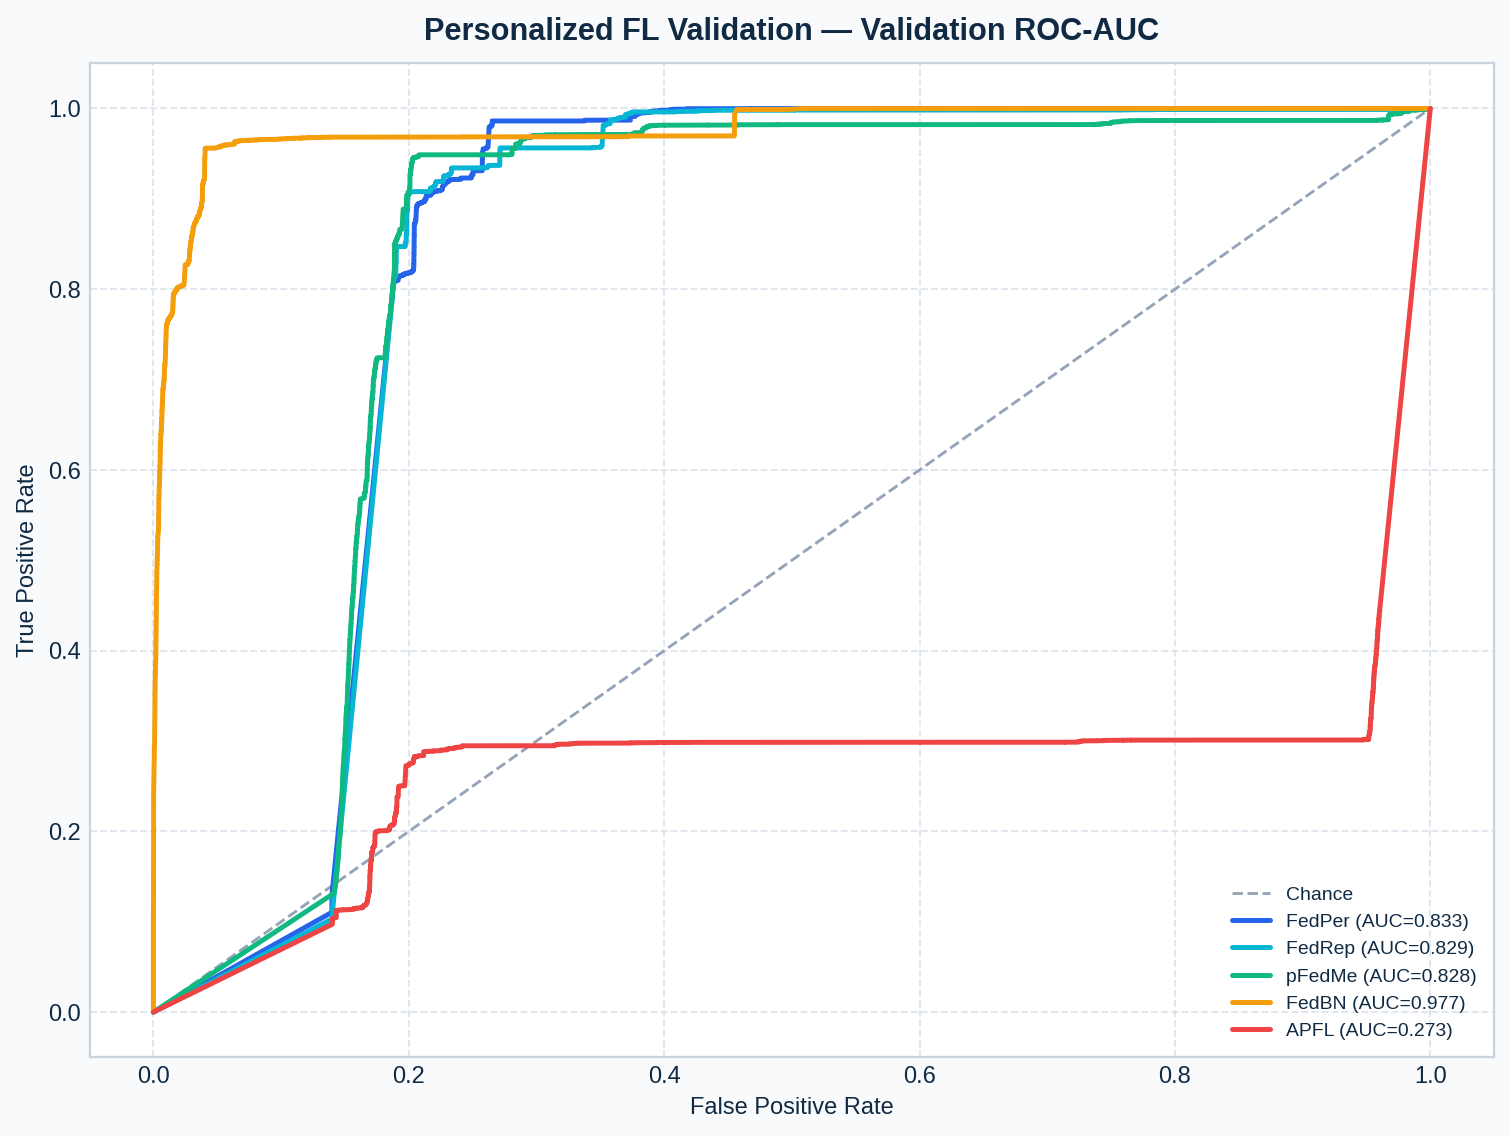

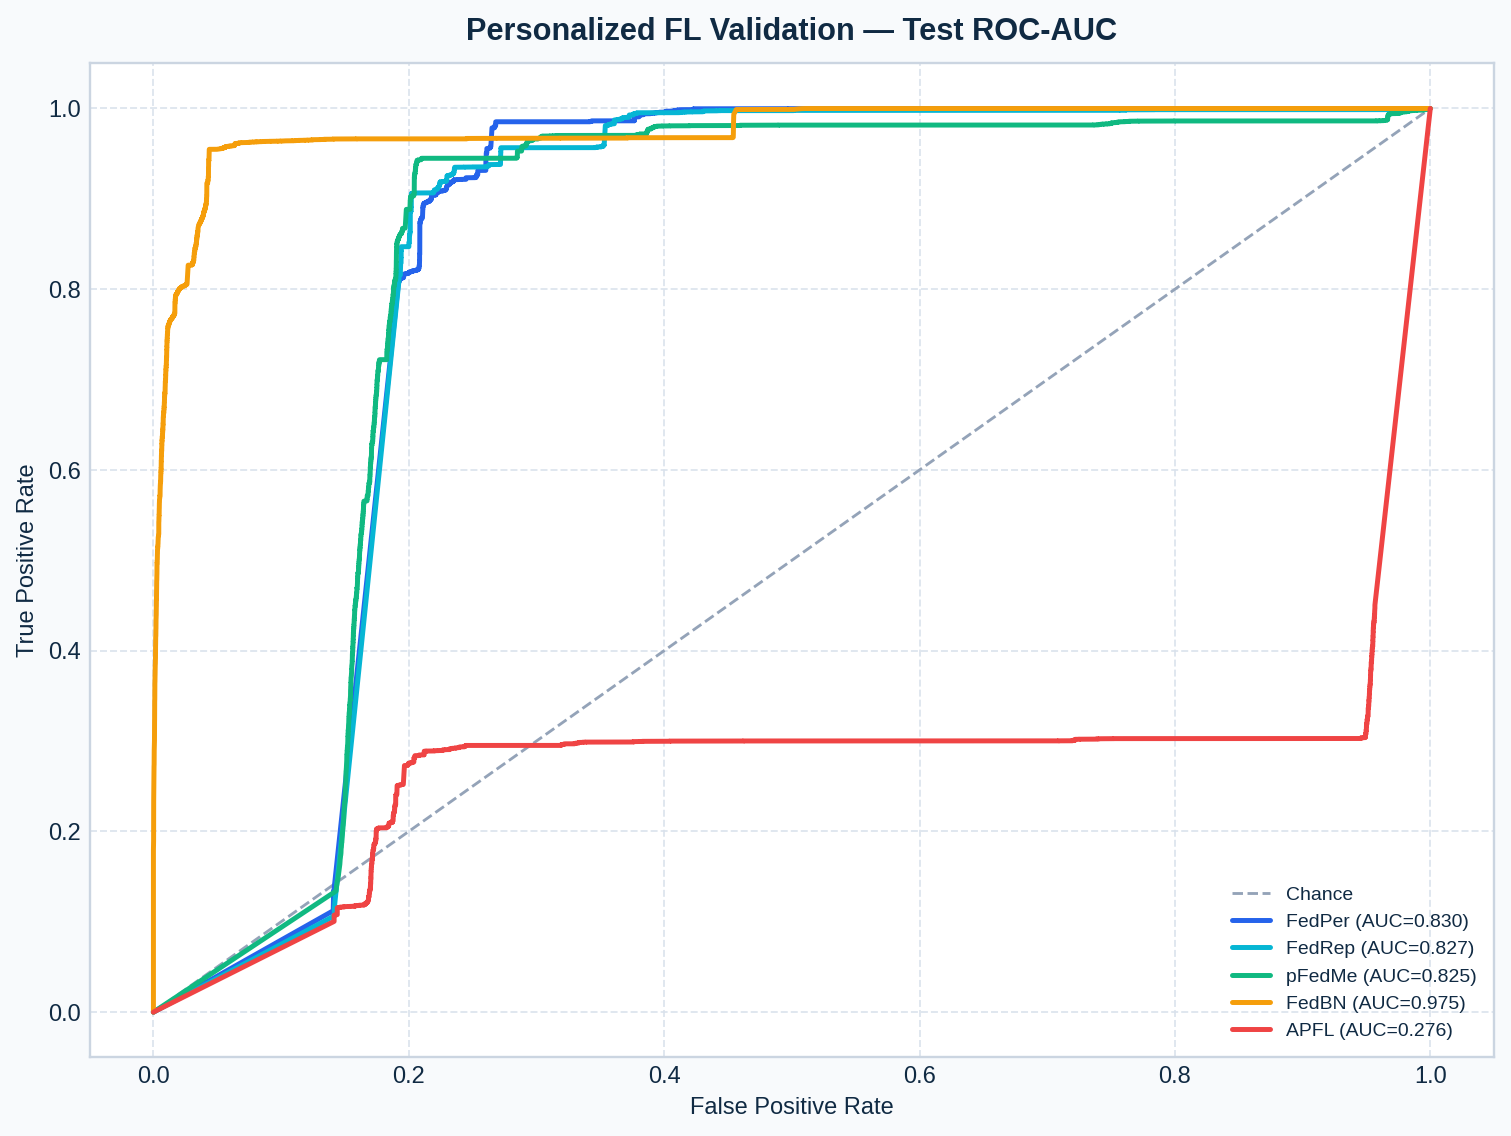

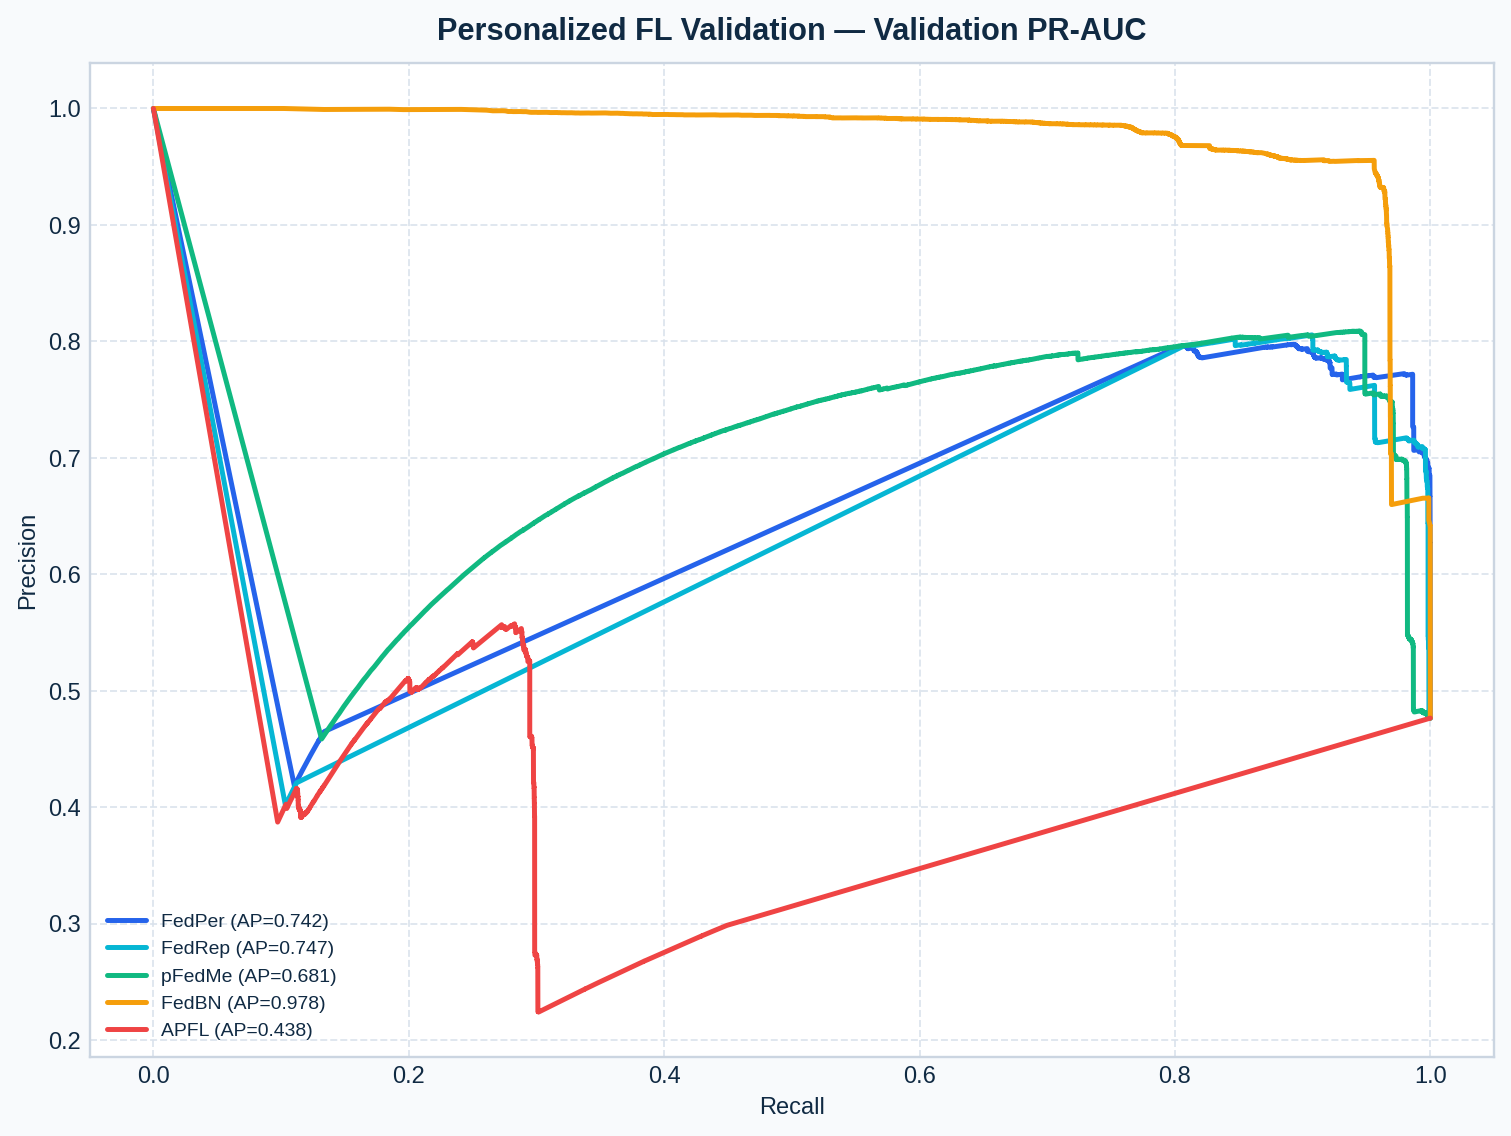

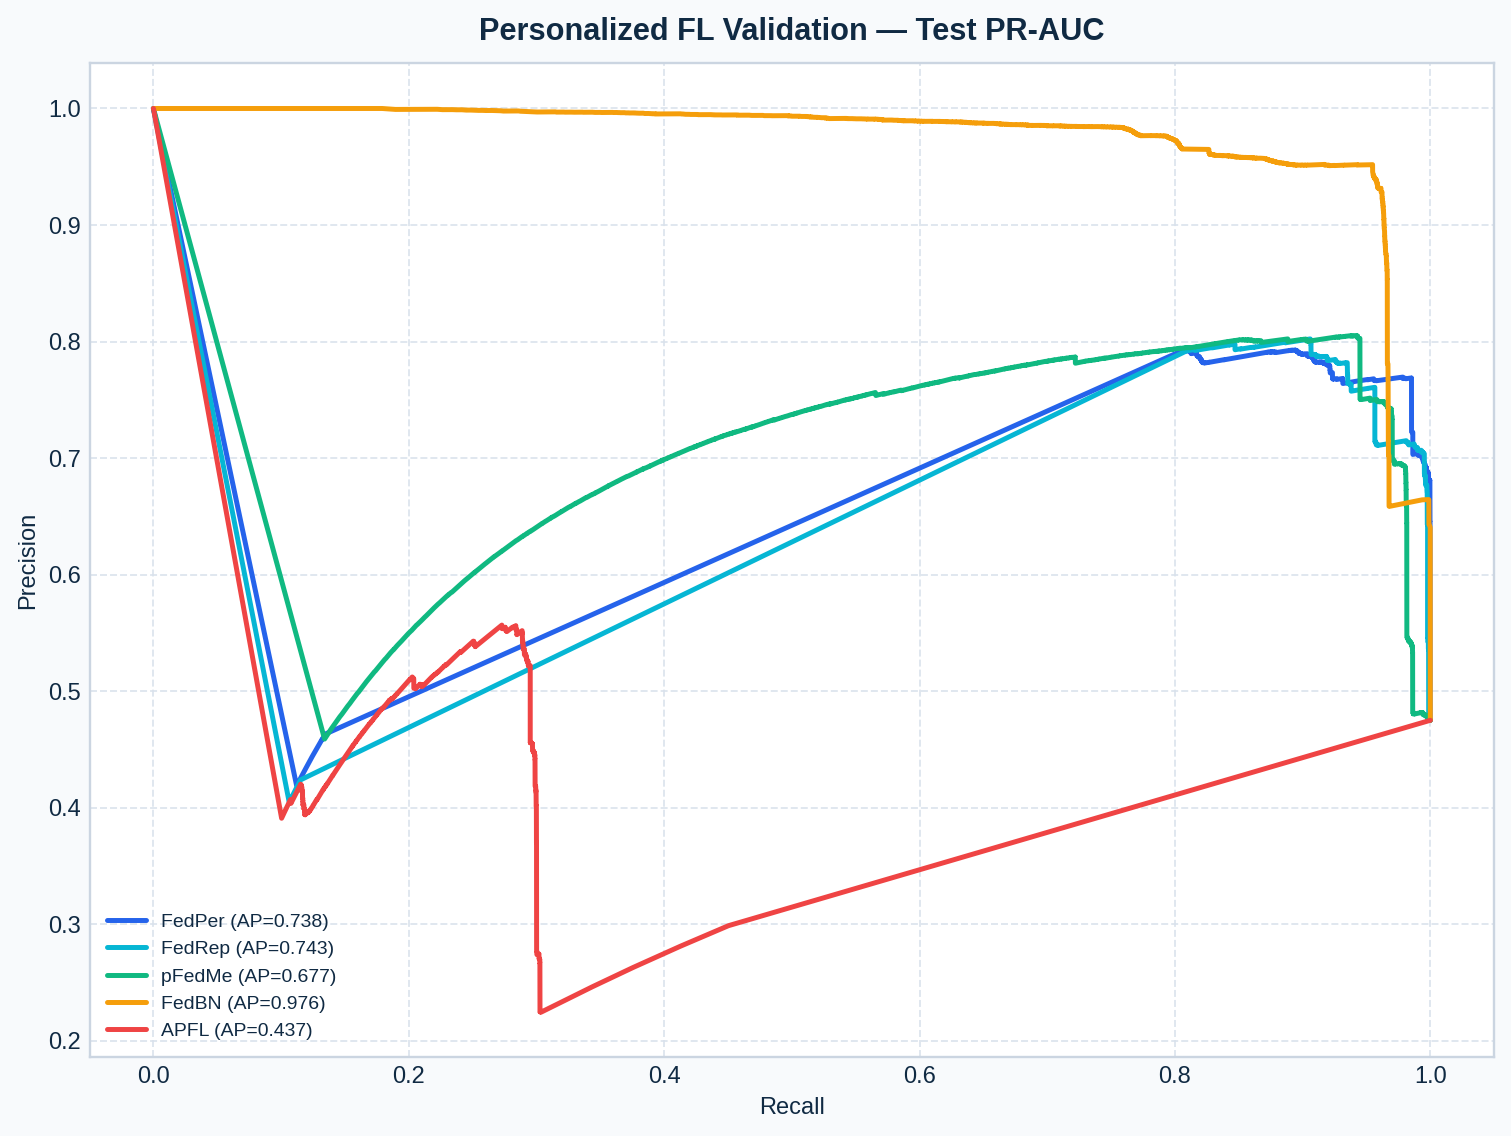

artifacts_baseline_validation_kaggle_colab/personalized_fl_validation_metrics.json
artifacts_baseline_validation_kaggle_colab/personalized_fl_validation_roc_pr_curves.json


In [15]:
# Kaggle/Colab baseline validation script
# GRIP-DFFI main model is excluded intentionally.
# Included: GRIP_DFFI_NO_FS, Centralized_Deep, FedAvg, FedPer, RF, XGBoost, SVM, MLP, ExtraTrees, LogReg
# Saves JSON metrics and ROC/PR curves only.

import os
import gc
import re
import glob
import json
import time
import math
import random
import warnings
import zlib
from io import BytesIO
from html import escape as html_escape
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

try:
    from IPython.display import display, HTML, Image as IPImage
    IN_NOTEBOOK = True
except Exception:
    HTML = None
    IN_NOTEBOOK = False

warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, log_loss, matthews_corrcoef, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve, cohen_kappa_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import kagglehub
    HAS_KAGGLEHUB = True
except Exception:
    kagglehub = None
    HAS_KAGGLEHUB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PIN_MEM = DEVICE == 'cuda'
NUM_WORKERS = 2 if DEVICE == 'cuda' else 0

PROCESS_NAME = 'GRIP-DFFI'
ART_DIR = 'artifacts_baseline_validation_kaggle_colab'
os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(os.path.join(ART_DIR, 'plots'), exist_ok=True)

ROUNDS = 15
LOCAL_EPOCHS = 1
LR = 1e-3
BATCH_SIZE = 256
CLASSICAL_MAX_TRAIN = 30000
CLASSICAL_MAX_EVAL = 20000
SHARED_HASH_BUCKETS = 4096
UNIVERSALITY_THRESHOLD = 0.60
MIN_SHARED_OCCURRENCE = 2
DIFFUSION_LOSS_WEIGHT = 0.05
DIFFUSION_STEPS = 20
FEATURE_INTEL_ROUNDS = 2
FEATURE_INTEL_STEPS = 60
FEATURE_INTEL_LR = 1e-2
FEATURE_INTEL_MI_WEIGHT = 0.55
FEATURE_INTEL_FRN_WEIGHT = 0.45
RL_POLICY_EPISODES = 70
RL_POLICY_LR = 0.18
CLIENT_DIRICHLET_ALPHA = 0.70
D_MODEL = 160
N_BLOCKS = 2
N_HEADS = 8
FF_DIM = 320
DROP = 0.10

BG_CLR = '#f8fafc'
PANEL_CLR = '#ffffff'
GRID_CLR = '#d9e2ec'
TEXT_CLR = '#102a43'
SUBTEXT_CLR = '#486581'
ACCENT_1 = '#2563eb'
ACCENT_2 = '#06b6d4'
ACCENT_3 = '#10b981'
ACCENT_4 = '#f97316'
ACCENT_5 = '#ef4444'
ACCENT_6 = '#8b5cf6'
PALETTE = ['#2563eb', '#06b6d4', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6', '#0ea5e9', '#22c55e', '#f97316', '#db2777', '#84cc16', '#7c3aed']

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': BG_CLR,
    'axes.facecolor': PANEL_CLR,
    'savefig.facecolor': BG_CLR,
    'axes.edgecolor': '#cbd5e1',
    'axes.labelcolor': TEXT_CLR,
    'xtick.color': TEXT_CLR,
    'ytick.color': TEXT_CLR,
    'text.color': TEXT_CLR,
    'axes.titlecolor': TEXT_CLR,
    'grid.color': GRID_CLR,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'axes.grid': True,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'legend.framealpha': 0.96,
    'legend.facecolor': 'white',
    'legend.edgecolor': '#d1d5db',
})

_TABLE_CSS_EMITTED = False

def _emit_table_css_once():
    global _TABLE_CSS_EMITTED
    if not IN_NOTEBOOK or _TABLE_CSS_EMITTED:
        return
    css = '''
    <style>
      .grip-table-block { margin: 12px 0 18px 0; border: 1px solid #dbe4ee; border-radius: 12px; overflow-x: auto; background: #ffffff; box-shadow: 0 1px 4px rgba(15, 23, 42, 0.05); }
      .grip-table-title { padding: 10px 14px; font-weight: 700; color: #0f172a; background: #f8fafc; border-bottom: 1px solid #e2e8f0; font-size: 15px; }
      .grip-table-block table.dataframe { border-collapse: separate !important; border-spacing: 0; width: max-content; min-width: 100%; margin: 0; font-size: 13px; }
      .grip-table-block table.dataframe thead th { position: sticky; top: 0; background: #eff6ff; color: #0f172a; text-align: left; padding: 9px 10px; border-bottom: 1px solid #cbd5e1; white-space: nowrap; }
      .grip-table-block table.dataframe tbody td { padding: 8px 10px; border-bottom: 1px solid #eef2f7; vertical-align: top; white-space: normal; word-break: break-word; }
      .grip-table-block table.dataframe tbody tr:nth-child(even) { background: #fcfdff; }
      .grip-table-block table.dataframe tbody tr:hover { background: #f8fbff; }
      .grip-note { color: #475569; font-size: 12px; margin: 6px 0 12px 2px; }
    </style>
    '''
    display(HTML(css))
    _TABLE_CSS_EMITTED = True

def _prepare_table_df(df, float_decimals=4):
    out = df.copy()
    for col in out.columns:
        vals = []
        for v in out[col].tolist():
            if isinstance(v, (float, np.floating)):
                vals.append('' if pd.isna(v) else f'{float(v):.{float_decimals}f}')
            elif isinstance(v, (int, np.integer)) and not isinstance(v, (bool, np.bool_)):
                vals.append(f'{int(v):,}')
            elif isinstance(v, (bool, np.bool_)):
                vals.append('True' if bool(v) else 'False')
            elif pd.isna(v):
                vals.append('')
            else:
                vals.append(str(v))
        out[col] = vals
    return out

def show_table(title, df, index=False, rename_map=None, columns=None, float_decimals=4, note=None):
    view = df.copy()
    if columns is not None:
        view = view[[c for c in columns if c in view.columns]]
    if rename_map is not None:
        view = view.rename(columns=rename_map)
    view = _prepare_table_df(view, float_decimals)
    if IN_NOTEBOOK:
        _emit_table_css_once()
        html_df = view.copy()
        html_df.columns = [html_escape(str(c)) for c in html_df.columns]
        for col in html_df.columns:
            html_df[col] = html_df[col].map(lambda s: html_escape(str(s)).replace('\n', '<br>'))
        table_html = html_df.to_html(index=index, escape=False, border=0)
        note_html = f'<div class="grip-note">{html_escape(str(note))}</div>' if note else ''
        display(HTML(f'<div class="grip-table-block"><div class="grip-table-title">{html_escape(str(title))}</div>{table_html}</div>{note_html}'))
    else:
        print('\n' + '=' * 100)
        print(title)
        print('-' * 100)
        try:
            print(view.to_markdown(index=index))
        except Exception:
            print(view.to_string(index=index))
        if note:
            print(note)
        print('=' * 100)


def save_or_show(fig, path=None):
    fig.tight_layout()
    if path is not None:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        fig.savefig(path, dpi=180, bbox_inches='tight')
    if IN_NOTEBOOK:
        buf = BytesIO()
        fig.savefig(buf, format='png', dpi=170, bbox_inches='tight')
        buf.seek(0)
        display(IPImage(data=buf.read()))
    plt.close(fig)


def prettify_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.set_facecolor(PANEL_CLR)
    for sp in ax.spines.values():
        sp.set_edgecolor('#cbd5e1')
    ax.grid(True, color=GRID_CLR, linestyle='--', linewidth=0.8, alpha=0.85)
    ax.tick_params(colors=TEXT_CLR)
    if title is not None:
        ax.set_title(title, pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

DATASET_SPECS = [
    {'name': 'I23Sub', 'source_type': 'kaggle', 'slug': 'wittigenz/hydras', 'domain_id': 0, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class_type'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack', 'Class'], 'normal_aliases': ['normal', 'benign', 'benign_traffic', 'background', 'legitimate', '0'], 'file_rank': None, 'unsw_nb15_raw': False},
    {'name': 'K99Sub', 'source_type': 'kaggle', 'slug': 'sampadab17/network-intrusion-detection', 'domain_id': 1, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class', 'Class'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack'], 'normal_aliases': ['normal', 'benign', '0'], 'file_rank': None, 'unsw_nb15_raw': False},
    {'name': 'NTD1', 'source_type': 'kaggle', 'slug': 'rebsonramalho/network-threat-detection-dataset', 'domain_id': 2, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class', 'Class'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack'], 'normal_aliases': ['normal', 'benign', 'benign_traffic', 'legitimate', '0'], 'file_rank': 0, 'unsw_nb15_raw': False},
    {'name': 'NTD2', 'source_type': 'kaggle', 'slug': 'rebsonramalho/network-threat-detection-dataset', 'domain_id': 3, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class', 'Class'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack'], 'normal_aliases': ['normal', 'benign', 'benign_traffic', 'legitimate', '0'], 'file_rank': 1, 'unsw_nb15_raw': False},
    {'name': 'WII21', 'source_type': 'kaggle', 'slug': 'annaamalaiu/wustl-iiot-2021-dataset', 'domain_id': 4, 'task_preference': 'multiclass', 'prefer_multiclass': ['attack_cat', 'attack_type', 'attack', 'category', 'type', 'class', 'Class', 'label'], 'prefer_binary': ['label', 'Label', 'binary_label', 'target', 'is_attack'], 'normal_aliases': ['normal', 'benign', 'benign_traffic', 'background', 'legitimate', '0'], 'file_rank': None, 'unsw_nb15_raw': False},
]

TARGET_LIKE_NAMES = {'label', 'target', 'class', 'y', 'outcome', 'attack_cat', 'attack', 'category', 'type', 'label_type', 'class_type', 'attack_type', 'binary_label', 'is_attack'}
UNSW_COLS = ['srcip','sport','dstip','dsport','proto','state','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','service','Sload','Dload','Spkts','Dpkts','swin','dwin','stcpb','dtcpb','smeansz','dmeansz','trans_depth','res_bdy_len','Sjit','Djit','Stime','Ltime','Sintpkt','Dintpkt','tcprtt','synack','ackdat','is_sm_ips_ports','ct_state_ttl','ct_flw_http_mthd','is_ftp_login','ct_ftp_cmd','ct_srv_src','ct_srv_dst','ct_dst_ltm','ct_src_ltm','ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','attack_cat','label']
IP_RE = re.compile(r'^\s*\d{1,3}(\.\d{1,3}){3}\s*$')
TRAIN_RE = re.compile(r'(?:^|[_\-\s])(train|training)(?:[_\-\s\.]|$)', re.I)
VAL_RE = re.compile(r'(?:^|[_\-\s])(val|valid|validation|dev)(?:[_\-\s\.]|$)', re.I)
TEST_RE = re.compile(r'(?:^|[_\-\s])(test|testing)(?:[_\-\s\.]|$)', re.I)

def _norm_name(s):
    return re.sub(r'[^a-z0-9]+', '', str(s).lower())


def resolve_dataset_path(spec):
    search_roots = [
        '/kaggle/input',
        '/content',
        '/content/data',
        '/content/datasets',
        '/content/drive/MyDrive',
        '/content/drive/MyDrive/datasets',
        '/content/drive/MyDrive/data',
    ]
    candidates = []
    slug_tail = spec.get('slug', '').split('/')[-1]
    candidates.extend([
        slug_tail,
        spec.get('name', ''),
    ])
    manual_aliases = {
        'I23Sub': ['iotnet24-dataset-for-ids', 'iotnet24 dataset for ids', 'hydras'],
        'K99Sub': ['network-intrusion-detection'],
        'NTD1': ['network-threat-detection-dataset'],
        'NTD2': ['network-threat-detection-dataset'],
        'WII21': ['wustl-iiot-2021-dataset', 'wustliiot2021dataset'],
    }
    candidates.extend(manual_aliases.get(spec.get('name', ''), []))
    candidates = [_norm_name(c) for c in candidates if c]

    for root in search_roots:
        if not os.path.isdir(root):
            continue
        subdirs = [os.path.join(root, d) for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
        norm_to_path = {_norm_name(os.path.basename(p)): p for p in subdirs}
        for cand in candidates:
            if cand in norm_to_path:
                return norm_to_path[cand]
        for cand in candidates:
            for n, p in norm_to_path.items():
                if cand and (cand in n or n in cand):
                    return p
        for sub in subdirs:
            nested = [os.path.join(sub, d) for d in os.listdir(sub) if os.path.isdir(os.path.join(sub, d))]
            norm_nested = {_norm_name(os.path.basename(p)): p for p in nested}
            for cand in candidates:
                if cand in norm_nested:
                    return norm_nested[cand]
            for cand in candidates:
                for n, p in norm_nested.items():
                    if cand and (cand in n or n in cand):
                        return p

    slug = spec['slug']
    if HAS_KAGGLEHUB:
        return kagglehub.dataset_download(slug)
    raise FileNotFoundError(
        f"Could not resolve dataset path for {spec.get('name', 'unknown')} in Kaggle/Colab roots, and kagglehub is unavailable."
    )


_download_cache = {}
for spec in DATASET_SPECS:
    slug = spec['slug']
    if slug not in _download_cache:
        _download_cache[slug] = resolve_dataset_path(spec)
    spec['path'] = _download_cache[slug]


def safe_norm(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.size == 0:
        return arr
    arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
    rng = arr.max() - arr.min()
    return (arr - arr.min()) / (rng + 1e-6)


def sanitize_numeric_1d(x, clip=1e6):
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=0.0, posinf=clip, neginf=-clip)
    x = np.clip(x, -clip, clip)
    return x.astype(np.float32)


def list_table_files(root):
    files = []
    for ext in ['csv', 'tsv', 'parquet']:
        files += glob.glob(os.path.join(root, f'**/*.{ext}'), recursive=True)
    return sorted(files)


def load_one(path, force_cols=None):
    if path.endswith('.csv'):
        if force_cols is not None:
            df = pd.read_csv(path, header=None, low_memory=False)
            if df.shape[1] == len(force_cols):
                first = df.iloc[0].astype(str).tolist()
                if any(v in force_cols for v in first):
                    df = df.iloc[1:].reset_index(drop=True)
                df.columns = force_cols
                return df
        return pd.read_csv(path, low_memory=False)
    if path.endswith('.tsv'):
        return pd.read_csv(path, sep='\t', low_memory=False)
    if path.endswith('.parquet'):
        return pd.read_parquet(path)
    raise ValueError(path)


def combine_tables(files, force_cols=None):
    dfs = []
    for fp in files:
        try:
            d = load_one(fp, force_cols=force_cols)
            if len(d) > 0:
                dfs.append(d)
        except Exception:
            pass
    if not dfs:
        return None
    cols = sorted(set().union(*[set(d.columns) for d in dfs]))
    aligned = []
    for d in dfs:
        dd = d.copy()
        for c in cols:
            if c not in dd.columns:
                dd[c] = np.nan
        aligned.append(dd[cols])
    return pd.concat(aligned, axis=0, ignore_index=True)


def categorize_split_files(files):
    groups = {'train': [], 'val': [], 'test': [], 'other': []}
    for fp in files:
        bn = os.path.basename(fp)
        if TRAIN_RE.search(bn):
            groups['train'].append(fp)
        elif VAL_RE.search(bn):
            groups['val'].append(fp)
        elif TEST_RE.search(bn):
            groups['test'].append(fp)
        else:
            groups['other'].append(fp)
    return groups


def choose_files_for_spec(spec, all_files):
    if spec.get('unsw_nb15_raw', False):
        nb_names = [f'UNSW-NB15_{i}.csv' for i in range(1, 5)]
        chosen = [f for f in all_files if os.path.basename(f) in nb_names]
        if not chosen:
            chosen = sorted(all_files, key=os.path.getsize, reverse=True)[:4]
        return sorted(chosen)
    if spec.get('file_rank') is not None:
        by_size = sorted(all_files, key=os.path.getsize, reverse=True)
        rank = int(spec['file_rank'])
        return [by_size[rank]]
    return all_files


def clean_target_series(s, spec=None):
    x = s.astype('string').fillna('missing').str.strip()
    x = x.replace({'': 'missing', 'nan': 'missing', 'None': 'missing', '<NA>': 'missing'})
    return x


def detect_target_column(df, spec):
    cols = list(df.columns)
    lower_map = {str(c).lower(): c for c in cols}
    def existing(cands):
        return [lower_map[str(c).lower()] for c in cands if str(c).lower() in lower_map]
    multiclass_cands = existing(spec.get('prefer_multiclass', []))
    binary_cands = existing(spec.get('prefer_binary', []))
    def viable(c, want_multi):
        vals = clean_target_series(df[c], spec)
        nunq = vals.nunique(dropna=True)
        if want_multi:
            return nunq > 2
        return nunq == 2
    if spec.get('task_preference', 'multiclass') == 'multiclass':
        for c in multiclass_cands:
            if viable(c, True):
                return c, 'multiclass'
        for c in binary_cands:
            if viable(c, False):
                return c, 'binary'
    else:
        for c in binary_cands:
            if viable(c, False):
                return c, 'binary'
        for c in multiclass_cands:
            if viable(c, True):
                return c, 'multiclass'
    for c in cols:
        if str(c).lower() in TARGET_LIKE_NAMES:
            vals = clean_target_series(df[c], spec)
            nunq = vals.nunique(dropna=True)
            if nunq > 2:
                return c, 'multiclass'
            if nunq == 2:
                return c, 'binary'
    raise RuntimeError(f"{spec['name']}: could not resolve a real target column")


def target_signature(y_series, spec):
    y = clean_target_series(pd.Series(y_series), spec)
    vals = set(y.dropna().astype(str).unique().tolist())
    vals = {v for v in vals if v != 'missing'}
    return vals


def target_compatible(train_y, other_y, spec):
    tr = target_signature(train_y, spec)
    ot = target_signature(other_y, spec)
    if len(tr) < 2 or len(ot) < 1:
        return False
    inter = tr & ot
    if tr == ot:
        return True
    if tr.issubset(ot) or ot.issubset(tr):
        return True
    overlap_ratio = len(inter) / max(min(len(tr), len(ot)), 1)
    if overlap_ratio >= 0.80:
        return True
    if tr.issubset({'0', '1'}) and ot.issubset({'0', '1'}):
        return True
    return False


def candidate_target_like_columns(df, target_col):
    keep_lower = str(target_col).lower()
    out = []
    for c in df.columns:
        cl = str(c).lower()
        if cl == keep_lower:
            continue
        if cl in TARGET_LIKE_NAMES or keep_lower in cl or cl in keep_lower:
            out.append(c)
    return out


def find_target_sibling_columns(Xtr, y_train_raw, target_col, spec, deterministic_threshold=0.995):
    y = clean_target_series(pd.Series(y_train_raw), spec).astype(str)
    drop_cols = []
    for c in candidate_target_like_columns(Xtr, target_col):
        s = clean_target_series(pd.Series(Xtr[c]), spec).astype(str)
        tmp = pd.DataFrame({'feat': s, 'target': y}).replace({'missing': np.nan}).dropna()
        if len(tmp) == 0:
            continue
        nunq_feat = int(tmp['feat'].nunique())
        nunq_tgt = int(tmp['target'].nunique())
        if nunq_feat <= 1 or nunq_tgt <= 1:
            continue
        per_feat_target_nunique = tmp.groupby('feat')['target'].nunique()
        deterministic_feat_to_target = int(per_feat_target_nunique.max()) == 1
        mean_majority_purity = float(tmp.groupby('feat')['target'].apply(lambda z: z.value_counts(normalize=True).iloc[0]).mean())
        if deterministic_feat_to_target and mean_majority_purity >= deterministic_threshold:
            drop_cols.append(c)
    return drop_cols


def drop_target_like_columns(X, keep_target, drop_cols=None):
    keep_lower = str(keep_target).lower()
    drop_cols = drop_cols or []
    safe_drop = [c for c in drop_cols if str(c).lower() != keep_lower and c in X.columns]
    return X.drop(columns=safe_drop, errors='ignore')


def drop_id_cols(X):
    n = len(X)
    explicit = {'id', 'uid', 'uuid', 'flow_id', 'record_id', 'srcip', 'dstip'}
    drop = []
    for c in X.columns:
        cl = str(c).lower()
        if cl in explicit:
            drop.append(c)
            continue
        if n >= 5000:
            try:
                if X[c].nunique(dropna=True) == n:
                    drop.append(c)
            except Exception:
                pass
    kept = [c for c in X.columns if c not in set(drop)]
    return X[kept].copy() if kept else X.copy()


def safe_stratify_labels(y_raw):
    vc = pd.Series(y_raw).value_counts()
    return y_raw if len(vc) > 1 and vc.min() >= 2 else None


def split_three_way(df, y_raw, seed=SEED):
    vc = pd.Series(y_raw).value_counts()
    valid = vc[vc >= 3].index
    mask = pd.Series(y_raw).isin(valid).to_numpy()
    df = df.loc[mask].reset_index(drop=True)
    y_raw = pd.Series(y_raw).loc[mask].reset_index(drop=True)
    X_tr, X_tmp, y_tr_raw, y_tmp_raw = train_test_split(df, y_raw, test_size=0.30, random_state=seed, stratify=safe_stratify_labels(y_raw))
    X_va, X_te, y_va_raw, y_te_raw = train_test_split(X_tmp, y_tmp_raw, test_size=0.50, random_state=seed, stratify=safe_stratify_labels(y_tmp_raw))
    return X_tr.reset_index(drop=True), pd.Series(y_tr_raw).reset_index(drop=True), X_va.reset_index(drop=True), pd.Series(y_va_raw).reset_index(drop=True), X_te.reset_index(drop=True), pd.Series(y_te_raw).reset_index(drop=True)


def infer_types(Xtr, thresh=0.90):
    num_cols, cat_cols = [], []
    for c in Xtr.columns:
        s = Xtr[c]
        if s.dtype == 'O' or str(s.dtype).startswith(('category', 'string')):
            sample = s.dropna().astype(str).head(250).tolist()
            if any(IP_RE.match(v) for v in sample):
                cat_cols.append(c)
                continue
            if pd.to_numeric(s, errors='coerce').notna().mean() >= thresh:
                num_cols.append(c)
            else:
                cat_cols.append(c)
        else:
            num_cols.append(c)
    cat_cols = [c for c in cat_cols if c not in num_cols]
    return num_cols, cat_cols


def fit_num_stats(Xtr, num_cols):
    means, stds = {}, {}
    for c in num_cols:
        s = pd.to_numeric(Xtr[c], errors='coerce')
        m = float(s.mean()) if s.notna().any() else 0.0
        sd = float(s.std()) if s.notna().any() else 1.0
        if not np.isfinite(sd) or sd < 1e-6:
            sd = 1.0
        means[c] = m
        stds[c] = sd
    return means, stds


def apply_num_cat_preproc(X, num_cols, cat_cols, means, stds):
    X = X.copy()
    for c in num_cols:
        s = pd.to_numeric(X[c], errors='coerce')
        s = s.fillna(means.get(c, 0.0))
        s = (s - means.get(c, 0.0)) / (stds.get(c, 1.0) + 1e-6)
        X[c] = s.astype(np.float32)
    for c in cat_cols:
        X[c] = X[c].astype('string').fillna('missing')
    return X


def fit_label_mapping(y_train_raw):
    uniq = pd.Index(pd.unique(y_train_raw.astype(str)))
    mapping = {v: i for i, v in enumerate(uniq.tolist())}
    return mapping, uniq.tolist()


def apply_label_mapping(y_raw, mapping):
    y = y_raw.astype(str).map(mapping)
    keep = y.notna()
    return y[keep].astype(int).to_numpy(), keep.to_numpy()


def detect_normal_index(class_names, spec=None):
    aliases = {'normal', 'benign', 'benign_traffic', 'background', 'legitimate'}
    if spec is not None:
        aliases |= set([str(x).lower() for x in spec.get('normal_aliases', [])])
    for i, name in enumerate(class_names):
        s = str(name).strip().lower()
        if s in aliases:
            return i
        if s == '0' and len(class_names) == 2:
            return i
    if len(class_names) == 2:
        names = [str(x) for x in class_names]
        if set(names) == {'0', '1'}:
            return names.index('0')
    return None


def to_binary_labels(y, class_names, normal_index):
    y = np.asarray(y).astype(int)
    if len(class_names) == 2:
        return y.copy()
    if normal_index is None:
        return (y != 0).astype(int)
    return (y != normal_index).astype(int)


def feature_key(name, kind):
    return f'{kind}::{name}'


def feature_name_from_key(key):
    return key.split('::', 1)[1]


def feature_kind_from_key(key):
    return key.split('::', 1)[0]


def deterministic_hash_value(text, mod=SHARED_HASH_BUCKETS):
    return zlib.crc32(str(text).encode('utf-8')) % mod


def hash_categorical_frame(X, cols, mod=SHARED_HASH_BUCKETS):
    if not cols:
        return np.zeros((len(X), 0), np.int64)
    out = np.zeros((len(X), len(cols)), dtype=np.int64)
    for j, c in enumerate(cols):
        vals = X[c].astype(str).fillna('missing').tolist()
        out[:, j] = np.array([deterministic_hash_value(f'{c}={v}', mod=mod) for v in vals], dtype=np.int64)
    return out


def cross_plan(Xtr, ytr, cat_cols, max_base=6, seed=SEED):
    rng = np.random.RandomState(seed)
    base = cat_cols[:min(max_base, len(cat_cols))]
    if len(base) < 2:
        return {'use_triples': False, 'base_cols': base}
    idx = rng.choice(len(Xtr), min(7000, len(Xtr)), replace=False)
    Xt, yt = Xtr.iloc[idx].copy(), ytr[idx]
    def mk(X, triples):
        Xc = X.copy()
        for i in range(len(base)):
            for j in range(i + 1, len(base)):
                Xc[f'xp_{i}_{j}'] = Xc[base[i]].astype(str) + '||' + Xc[base[j]].astype(str)
        if triples and len(base) >= 3:
            for i in range(len(base)):
                for j in range(i + 1, len(base)):
                    for k in range(j + 1, len(base)):
                        Xc[f'xt_{i}_{j}_{k}'] = Xc[base[i]].astype(str) + '||' + Xc[base[j]].astype(str) + '||' + Xc[base[k]].astype(str)
        return Xc
    def mi_sc(Xc):
        cols = [c for c in Xc.columns if c.startswith(('xp_', 'xt_'))]
        if not cols:
            return 0.0
        M = np.stack([pd.factorize(Xc[c].astype(str).fillna('missing'))[0].astype(np.float32) for c in cols], axis=1)
        mi = mutual_info_classif(M, yt, discrete_features=True, random_state=SEED)
        return float(np.nan_to_num(mi).mean())
    sp = mi_sc(mk(Xt, False))
    st = mi_sc(mk(Xt, True))
    return {'use_triples': st > sp * 1.03, 'base_cols': base}


def apply_crosses(X, plan):
    X = X.copy()
    base = plan['base_cols']
    new = []
    if len(base) >= 2:
        for i in range(len(base)):
            for j in range(i + 1, len(base)):
                cn = f'cross_{base[i]}__{base[j]}'
                X[cn] = X[base[i]].astype(str) + '||' + X[base[j]].astype(str)
                new.append(cn)
    if plan['use_triples'] and len(base) >= 3:
        for i in range(len(base)):
            for j in range(i + 1, len(base)):
                for k in range(j + 1, len(base)):
                    cn = f'cross_{base[i]}__{base[j]}__{base[k]}'
                    X[cn] = X[base[i]].astype(str) + '||' + X[base[j]].astype(str) + '||' + X[base[k]].astype(str)
                    new.append(cn)
    return X, new


def compute_mi(Xtr, ytr, num_cols, cat_cols, max_rows=9000):
    yarr = np.asarray(ytr)
    if len(Xtr) > max_rows:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(Xtr), max_rows, replace=False)
        Xt = Xtr.iloc[idx].reset_index(drop=True)
        yt = yarr[idx]
    else:
        Xt = Xtr.reset_index(drop=True)
        yt = yarr
    M, disc, names = [], [], []
    for c in num_cols:
        if c in Xt.columns:
            M.append(sanitize_numeric_1d(pd.to_numeric(Xt[c], errors='coerce').to_numpy()))
            disc.append(False)
            names.append(c)
    for c in cat_cols:
        if c in Xt.columns:
            cd, _ = pd.factorize(Xt[c].astype(str).fillna('missing'))
            M.append(cd.astype(np.float32))
            disc.append(True)
            names.append(c)
    if not M:
        return [], np.array([], np.float32)
    Xmi = np.stack(M, axis=1)
    mi = mutual_info_classif(Xmi, yt, discrete_features=disc, random_state=SEED)
    return names, np.nan_to_num(mi).astype(np.float32)


class DenseDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def dense_from_flat_ds(ds, meta, n_global_ids):
    X = np.zeros((len(ds), n_global_ids), np.float32)
    if meta['n_num']:
        X[:, meta['num_global_ids']] = ds.xn.cpu().numpy()
    if meta['n_cat']:
        X[:, meta['cat_global_ids']] = ds.xc.cpu().numpy().astype(np.float32)
    y = ds.y.cpu().numpy()
    return X, y

def build_dense_clients(flat_view, n_global_ids):
    dense_view = []
    for v in flat_view:
        Xtr, ytr = dense_from_flat_ds(v['tr'], v['meta'], n_global_ids)
        Xva, yva = dense_from_flat_ds(v['va'], v['meta'], n_global_ids)
        Xte, yte = dense_from_flat_ds(v['te'], v['meta'], n_global_ids)
        clients = []
        for idx in v['cidx']:
            clients.append((Xtr[idx], ytr[idx]))
        dense_view.append({
            'name': v['meta']['name'],
            'tr': (Xtr, ytr),
            'va': (Xva, yva),
            'te': (Xte, yte),
            'clients': clients,
        })
    return dense_view

class DenseBackboneHead(nn.Module):
    def __init__(self, in_dim, hid1=256, hid2=128, n_classes=2, use_bn=False):
        super().__init__()
        layers = [nn.Linear(in_dim, hid1)]
        if use_bn:
            layers.append(nn.BatchNorm1d(hid1))
        layers += [nn.GELU(), nn.Dropout(0.10), nn.Linear(hid1, hid2)]
        if use_bn:
            layers.append(nn.BatchNorm1d(hid2))
        layers += [nn.GELU(), nn.Dropout(0.10)]
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(hid2, n_classes)
    def forward(self, x):
        z = self.backbone(x)
        return self.head(z)

def state_to_cpu(module):
    return {k: v.detach().cpu().clone() for k, v in module.state_dict().items()}

def load_state_safe(module, sd):
    module.load_state_dict(sd, strict=True)

def average_dense_states(states, weights, exclude_bn=False, keys_filter=None):
    if not states:
        return {}
    out = {}
    keys = states[0].keys()
    for k in keys:
        if keys_filter is not None and not keys_filter(k):
            continue
        if exclude_bn and ('running_mean' in k or 'running_var' in k or 'num_batches_tracked' in k):
            continue
        out[k] = sum(w * s[k] for s, w in zip(states, weights))
    return out

def merge_states(base_state, update_state):
    out = {k: v.clone() for k, v in base_state.items()}
    for k, v in update_state.items():
        out[k] = v.clone()
    return out

def predict_dense(model, X, batch_size=2048):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size], dtype=torch.float32, device=DEVICE)
            out.append(torch.softmax(model(xb), dim=1).cpu().numpy())
    return np.concatenate(out, axis=0)

def train_dense_local(model, X, y, epochs=1, lr=1e-3, wd=1e-4, prox_state=None, prox_mu=0.0, train_backbone=True, train_head=True):
    for p in model.backbone.parameters():
        p.requires_grad = train_backbone
    for p in model.head.parameters():
        p.requires_grad = train_head
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=wd)
    ds = DenseDataset(X, y)
    loader = DataLoader(ds, batch_size=min(BATCH_SIZE, max(128, len(ds))), shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEM, drop_last=False)
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            if xb.size(0) < 2:
                continue
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            if prox_state is not None and prox_mu > 0.0:
                prox = 0.0
                for n, p in model.named_parameters():
                    prox = prox + torch.sum((p - prox_state[n].to(DEVICE)) ** 2)
                loss = loss + 0.5 * prox_mu * prox
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()

def weighted_metric_bundle(metric_list, sizes):
    return weighted_metrics(metric_list, sizes)

def gather_eval_dense(view, models):
    val_metrics_each, test_metrics_each = [], []
    yv_all, pv_all, yt_all, pt_all = [], [], [], []
    for v, model in zip(view, models):
        Xva, yva = v['va']
        Xte, yte = v['te']
        Xva_s, yva_s = sample_if_needed(Xva, yva, CLASSICAL_MAX_EVAL, SEED + 910 + len(yv_all))
        Xte_s, yte_s = sample_if_needed(Xte, yte, CLASSICAL_MAX_EVAL, SEED + 920 + len(yt_all))
        pva = predict_dense(model, Xva_s)
        pte = predict_dense(model, Xte_s)
        val_metrics_each.append(compute_metrics(yva_s, pva))
        test_metrics_each.append(compute_metrics(yte_s, pte))
        yv_all.append(yva_s); pv_all.append(pva); yt_all.append(yte_s); pt_all.append(pte)
    yv = np.concatenate(yv_all, axis=0)
    pv = np.concatenate(pv_all, axis=0)
    yt = np.concatenate(yt_all, axis=0)
    pt = np.concatenate(pt_all, axis=0)
    return {
        'val_metrics': weighted_metric_bundle(val_metrics_each, [len(y) for y in yv_all]),
        'test_metrics': weighted_metric_bundle(test_metrics_each, [len(y) for y in yt_all]),
        'val_curve': build_curve_store(yv, pv),
        'test_curve': build_curve_store(yt, pt),
    }

def init_models_for_view(view, in_dim, use_bn=False):
    models = []
    for i, _ in enumerate(view):
        torch.manual_seed(SEED + i)
        m = DenseBackboneHead(in_dim=in_dim, use_bn=use_bn).to(DEVICE)
        models.append(m)
    return models

def run_fedper_dense(name, view, n_global_ids):
    models = init_models_for_view(view, n_global_ids, use_bn=False)
    global_backbone = state_to_cpu(models[0].backbone)
    for _ in range(2):
        local_backbones, weights = [], []
        for i, v in enumerate(view):
            m = models[i]
            load_state_safe(m.backbone, global_backbone)
            for Xc, yc in v['clients']:
                train_dense_local(m, Xc, yc, epochs=1, lr=LR, train_backbone=True, train_head=True)
            local_backbones.append(state_to_cpu(m.backbone))
            weights.append(sum(len(yc) for _, yc in v['clients']))
        weights = np.array(weights, np.float32); weights = weights / weights.sum()
        global_backbone = average_dense_states(local_backbones, weights)
    for m in models:
        load_state_safe(m.backbone, global_backbone)
    res = gather_eval_dense(view, models)
    res['method'] = name
    return res

def run_fedrep_dense(name, view, n_global_ids):
    models = init_models_for_view(view, n_global_ids, use_bn=False)
    global_backbone = state_to_cpu(models[0].backbone)
    for _ in range(2):
        local_backbones, weights = [], []
        for i, v in enumerate(view):
            m = models[i]
            load_state_safe(m.backbone, global_backbone)
            for Xc, yc in v['clients']:
                train_dense_local(m, Xc, yc, epochs=1, lr=LR, train_backbone=False, train_head=True)
                train_dense_local(m, Xc, yc, epochs=1, lr=LR, train_backbone=True, train_head=False)
            local_backbones.append(state_to_cpu(m.backbone))
            weights.append(sum(len(yc) for _, yc in v['clients']))
        weights = np.array(weights, np.float32); weights = weights / weights.sum()
        global_backbone = average_dense_states(local_backbones, weights)
    for m in models:
        load_state_safe(m.backbone, global_backbone)
    res = gather_eval_dense(view, models)
    res['method'] = name
    return res

def run_pfedme_dense(name, view, n_global_ids, prox_mu=0.01):
    models = init_models_for_view(view, n_global_ids, use_bn=False)
    global_state = state_to_cpu(models[0])
    for _ in range(2):
        local_states, weights = [], []
        for i, v in enumerate(view):
            m = models[i]
            load_state_safe(m, global_state)
            prox_state = {k: v.cpu().clone() for k, v in global_state.items()}
            for Xc, yc in v['clients']:
                train_dense_local(m, Xc, yc, epochs=1, lr=LR, prox_state=prox_state, prox_mu=prox_mu, train_backbone=True, train_head=True)
            local_states.append(state_to_cpu(m))
            weights.append(sum(len(yc) for _, yc in v['clients']))
        weights = np.array(weights, np.float32); weights = weights / weights.sum()
        global_state = average_dense_states(local_states, weights)
    for m in models:
        load_state_safe(m, global_state)
    res = gather_eval_dense(view, models)
    res['method'] = name
    return res

def run_fedbn_dense(name, view, n_global_ids):
    models = init_models_for_view(view, n_global_ids, use_bn=True)
    global_state = state_to_cpu(models[0])
    for _ in range(2):
        local_states, weights = [], []
        for i, v in enumerate(view):
            m = models[i]
            base = state_to_cpu(m)
            merged = merge_states(base, {k: vv for k, vv in global_state.items() if not ('running_mean' in k or 'running_var' in k or 'num_batches_tracked' in k)})
            load_state_safe(m, merged)
            for Xc, yc in v['clients']:
                train_dense_local(m, Xc, yc, epochs=1, lr=LR, train_backbone=True, train_head=True)
            local_states.append(state_to_cpu(m))
            weights.append(max(1, sum(len(yc) for _, yc in v['clients'])))
        weights = np.array(weights, np.float32); weights = weights / weights.sum()
        global_state = average_dense_states(local_states, weights, exclude_bn=True)
    res = gather_eval_dense(view, models)
    res['method'] = name
    return res

def run_apfl_dense(name, view, n_global_ids, alpha_mix=0.5):
    global_model = DenseBackboneHead(in_dim=n_global_ids, use_bn=False).to(DEVICE)
    local_models = init_models_for_view(view, n_global_ids, use_bn=False)
    global_state = state_to_cpu(global_model)
    for _ in range(2):
        local_states, weights = [], []
        for i, v in enumerate(view):
            g_model = DenseBackboneHead(in_dim=n_global_ids, use_bn=False).to(DEVICE)
            load_state_safe(g_model, global_state)
            l_model = local_models[i]
            for Xc, yc in v['clients']:
                train_dense_local(g_model, Xc, yc, epochs=1, lr=LR, train_backbone=True, train_head=True)
                train_dense_local(l_model, Xc, yc, epochs=1, lr=LR, train_backbone=True, train_head=True)
            local_states.append(state_to_cpu(g_model))
            weights.append(sum(len(yc) for _, yc in v['clients']))
        weights = np.array(weights, np.float32); weights = weights / weights.sum()
        global_state = average_dense_states(local_states, weights)
    mixed_models = []
    for i, _ in enumerate(view):
        g_model = DenseBackboneHead(in_dim=n_global_ids, use_bn=False).to(DEVICE)
        load_state_safe(g_model, global_state)
        l_model = local_models[i]
        mixed = {}
        gs = state_to_cpu(g_model); ls = state_to_cpu(l_model)
        for k in gs.keys():
            mixed[k] = alpha_mix * ls[k] + (1.0 - alpha_mix) * gs[k]
        m = DenseBackboneHead(in_dim=n_global_ids, use_bn=False).to(DEVICE)
        load_state_safe(m, mixed)
        mixed_models.append(m)
    res = gather_eval_dense(view, mixed_models)
    res['method'] = name
    return res


class GraphRefinedRelevanceNet(nn.Module):
    def __init__(self, in_dim=2, hid=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hid)
        self.fc2 = nn.Linear(hid, hid)
        self.out = nn.Linear(hid, 1)
    def forward(self, X, A):
        h = F.relu(self.fc1(A @ X))
        h = F.relu(self.fc2(A @ h))
        return torch.sigmoid(self.out(h)).squeeze(1)


def build_feature_graph(Xtr, ytr, feat_names, num_cols, cat_cols, max_rows=8000, top_e=8):
    if not feat_names:
        return np.zeros((0, 2), np.float32), np.zeros((0, 0), np.float32)
    if len(Xtr) > max_rows:
        idx = np.random.choice(len(Xtr), max_rows, replace=False)
        Xt, yt = Xtr.iloc[idx], ytr[idx]
    else:
        Xt, yt = Xtr, ytr
    M, disc, names = [], [], []
    for c in num_cols:
        if c in Xt.columns:
            M.append(sanitize_numeric_1d(pd.to_numeric(Xt[c], errors='coerce').to_numpy()))
            disc.append(False)
            names.append(c)
    for c in cat_cols:
        if c in Xt.columns:
            cd, _ = pd.factorize(Xt[c].astype(str).fillna('missing'))
            M.append(cd.astype(np.float32))
            disc.append(True)
            names.append(c)
    Fdim = len(feat_names)
    if not M:
        return np.zeros((Fdim, 2), np.float32), np.eye(Fdim, dtype=np.float32)
    Mm = np.stack(M, axis=1)
    mi = mutual_info_classif(Mm, yt, discrete_features=disc, random_state=SEED)
    mi = np.nan_to_num(mi)
    mi_map = {names[i]: float(mi[i]) for i in range(len(names))}
    mi_v, var_v = [], []
    for f in feat_names:
        mi_v.append(mi_map.get(f, 0.0))
        if f in num_cols and f in Xt.columns:
            vals = sanitize_numeric_1d(pd.to_numeric(Xt[f], errors='coerce').to_numpy())
            var_v.append(float(np.nanstd(vals)))
        else:
            var_v.append(float(Xt[f].astype(str).nunique() / max(len(Xt), 1)) if f in Xt.columns else 0.0)
    Xn = np.stack([np.array(mi_v, np.float32), np.array(var_v, np.float32)], axis=1)
    Xn = (Xn - Xn.mean(0, keepdims=True)) / (Xn.std(0, keepdims=True) + 1e-6)
    A = np.eye(Fdim, dtype=np.float32)
    ni = [i for i, f in enumerate(feat_names) if f in num_cols and f in Xt.columns]
    if len(ni) >= 2:
        Xnm = np.stack([sanitize_numeric_1d(pd.to_numeric(Xt[feat_names[i]], errors='coerce').to_numpy()) for i in ni], axis=1)
        C = np.nan_to_num(np.corrcoef(Xnm, rowvar=False))
        for ii, i in enumerate(ni):
            for jj in np.argsort(np.abs(C[ii]))[::-1][1:top_e + 1]:
                j = ni[jj]
                A[i, j] = max(A[i, j], float(abs(C[ii, jj])))
                A[j, i] = max(A[j, i], float(abs(C[ii, jj])))
    ci_idx = [i for i, f in enumerate(feat_names) if f in cat_cols and f in Xt.columns]
    for i in ci_idx:
        sv = set(Xt[feat_names[i]].astype(str).value_counts().head(20).index)
        for j in ci_idx:
            if j <= i:
                continue
            sw = set(Xt[feat_names[j]].astype(str).value_counts().head(20).index)
            sim = len(sv & sw) / (len(sv | sw) + 1e-6)
            if sim > 0.15:
                A[i, j] = A[j, i] = max(A[i, j], float(sim))
    D = A.sum(1)
    Dinv = 1.0 / np.sqrt(D + 1e-6)
    A = (A * Dinv[:, None]) * Dinv[None, :]
    return Xn.astype(np.float32), A.astype(np.float32)


def train_graph_refined_relevance_net(Xnode, A, steps=FEATURE_INTEL_STEPS, lr=FEATURE_INTEL_LR, init_state=None):
    if Xnode.shape[0] == 0:
        net = GraphRefinedRelevanceNet(in_dim=2, hid=32)
        if init_state is not None:
            try:
                net.load_state_dict(init_state, strict=False)
            except Exception:
                pass
        return net.state_dict(), np.array([], dtype=np.float32)
    Xt = torch.tensor(Xnode, dtype=torch.float32)
    At = torch.tensor(A, dtype=torch.float32)
    net = GraphRefinedRelevanceNet(in_dim=Xt.shape[1], hid=32)
    if init_state is not None:
        try:
            net.load_state_dict(init_state, strict=False)
        except Exception:
            pass
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    mi_col = Xt[:, 0]
    mi_norm = (mi_col - mi_col.min()) / (mi_col.max() - mi_col.min() + 1e-6)
    for _ in range(steps):
        opt.zero_grad()
        pred = net(Xt, At)
        loss = F.mse_loss(pred, mi_norm.detach())
        loss.backward()
        opt.step()
    with torch.no_grad():
        scores = net(Xt, At).cpu().numpy()
    return net.state_dict(), scores


def score_graph_refined_relevance_net(Xnode, A, state):
    if Xnode.shape[0] == 0:
        return np.array([], dtype=np.float32)
    Xt = torch.tensor(Xnode, dtype=torch.float32)
    At = torch.tensor(A, dtype=torch.float32)
    net = GraphRefinedRelevanceNet(in_dim=Xt.shape[1], hid=32)
    if state is not None:
        net.load_state_dict(state, strict=False)
    with torch.no_grad():
        return net(Xt, At).cpu().numpy().astype(np.float32)


def average_state_dicts(states, weights):
    out = {}
    for k in states[0]:
        out[k] = sum(weights[i] * states[i][k] for i in range(len(states)))
    return out


def rl_inspired_logistic_subset_policy(feat_names, scores, eps=RL_POLICY_EPISODES, lr=RL_POLICY_LR, min_pct=0.30, max_pct=0.90):
    n = len(feat_names)
    if n == 0:
        return feat_names
    if n <= 3:
        return feat_names
    sc = (scores - scores.mean()) / (scores.std() + 1e-6)
    logits = np.zeros(n, np.float32)
    min_k = max(1, int(min_pct * n))
    max_k = max(min_k + 1, int(max_pct * n))
    for _ in range(eps):
        p = 1.0 / (1.0 + np.exp(-logits))
        sel = np.random.rand(n) < p
        if sel.sum() == 0:
            sel[np.argmax(p)] = True
        k_sel = int(sel.sum())
        if k_sel < min_k:
            size_pen = (min_k - k_sel) / max(min_k, 1)
        elif k_sel > max_k:
            size_pen = (k_sel - max_k) / max(n - max_k, 1)
        else:
            size_pen = 0.0
        quality = float(sc[sel].mean())
        diversity = float(np.std(sc[sel])) * 0.10
        reward = quality + diversity - 0.40 * size_pen
        logits += lr * (sel.astype(np.float32) - p) * reward
    p = 1.0 / (1.0 + np.exp(-logits))
    sel_mask = p >= 0.50
    if sel_mask.sum() < min_k:
        sel_mask = np.zeros(n, bool)
        sel_mask[np.argsort(p)[::-1][:min_k]] = True
    return [feat_names[i] for i in np.where(sel_mask)[0]]


def compute_feature_universality(stage_records, score_key='global_relevance_map', min_occ=MIN_SHARED_OCCURRENCE):
    score_bank = defaultdict(list)
    for st in stage_records:
        for k, v in st.get(score_key, {}).items():
            score_bank[k].append(float(v))
    raw_var = {}
    occ = {k: len(v) for k, v in score_bank.items()}
    for k, vals in score_bank.items():
        raw_var[k] = float(np.var(vals)) if len(vals) >= 2 else 1.0
    vmax = max(raw_var.values()) if raw_var else 1.0
    uni = {}
    for k, v in raw_var.items():
        base = 1.0 - (v / (vmax + 1e-6))
        if occ.get(k, 0) < min_occ:
            base *= 0.35
        uni[k] = float(np.clip(base, 0.0, 1.0))
    return uni, occ


def entropy_adaptive_client_ratio(ytr):
    y_shift = np.asarray(ytr).astype(int) - np.asarray(ytr).astype(int).min()
    n_cls = len(np.unique(y_shift))
    counts = np.bincount(y_shift, minlength=n_cls).astype(float)
    probs = counts / (counts.sum() + 1e-9)
    entropy = -np.sum(probs * np.log(probs + 1e-9))
    return float(np.clip(entropy / (np.log(n_cls + 1e-9) + 1e-9), 0.0, 1.0))


def choose_num_clients(n, ytr):
    ratio = entropy_adaptive_client_ratio(ytr)
    if n <= 30000:
        lo, hi = 1, 4
    elif n <= 300000:
        lo, hi = 8, 12
    else:
        lo, hi = 13, 100
    return int(np.clip(round(lo + ratio * (hi - lo)), lo, hi))


def make_client_indices(ytr, n_clients, alpha=CLIENT_DIRICHLET_ALPHA, seed=SEED):
    rng = np.random.RandomState(seed)
    ys = np.asarray(ytr)
    classes = np.unique(ys)
    client_bins = [[] for _ in range(n_clients)]
    for cls in classes:
        idx = np.where(ys == cls)[0]
        rng.shuffle(idx)
        if len(idx) < n_clients:
            chunks = np.array_split(idx, n_clients)
        else:
            props = rng.dirichlet(np.ones(n_clients) * alpha)
            cuts = (np.cumsum(props) * len(idx)).astype(int)[:-1]
            chunks = np.split(idx, cuts)
        for cid, ch in enumerate(chunks):
            client_bins[cid].extend(ch.tolist())
    empties = [i for i, arr in enumerate(client_bins) if len(arr) == 0]
    for e in empties:
        donors = sorted(range(n_clients), key=lambda k: len(client_bins[k]), reverse=True)
        for d in donors:
            if len(client_bins[d]) > 1:
                client_bins[e].append(client_bins[d].pop())
                break
    out = []
    for arr in client_bins:
        arr = np.array(arr, dtype=np.int64)
        rng.shuffle(arr)
        out.append(arr)
    return out


def prepare_stage(spec):
    files_all = list_table_files(spec['path'])
    if not files_all:
        raise RuntimeError(f"{spec['name']}: no files found")
    selected_files = choose_files_for_spec(spec, files_all)
    groups = categorize_split_files(selected_files)
    force_cols = UNSW_COLS if spec.get('unsw_nb15_raw', False) else None
    df_train = combine_tables(groups['train'], force_cols=force_cols) if groups['train'] else None
    df_val = combine_tables(groups['val'], force_cols=force_cols) if groups['val'] else None
    df_test = combine_tables(groups['test'], force_cols=force_cols) if groups['test'] else None
    merged_source = None
    target_col = None
    task_kind = None
    if df_train is not None:
        target_col, task_kind = detect_target_column(df_train, spec)
        merge_parts = []
        if target_col in df_train.columns:
            merge_parts.append(df_train)
        if df_test is not None and target_col in df_test.columns and target_compatible(df_train[target_col], df_test[target_col], spec):
            merge_parts.append(df_test)
        if df_val is not None and target_col in df_val.columns and target_compatible(df_train[target_col], df_val[target_col], spec):
            merge_parts.append(df_val)
        merged_source = pd.concat(merge_parts, axis=0, ignore_index=True) if merge_parts else None
    if merged_source is None:
        merged_source = combine_tables(selected_files, force_cols=force_cols)
        target_col, task_kind = detect_target_column(merged_source, spec)
    df_full = merged_source.dropna(subset=[target_col]).reset_index(drop=True)
    y_full_raw = clean_target_series(df_full[target_col], spec).reset_index(drop=True)
    df_train, y_train_raw, df_val, y_val_raw, df_test, y_test_raw = split_three_way(df_full, y_full_raw, seed=SEED)
    Xtr = df_train.drop(columns=[target_col], errors='ignore').copy()
    Xva = df_val.drop(columns=[target_col], errors='ignore').copy()
    Xte = df_test.drop(columns=[target_col], errors='ignore').copy()
    sibling_drop = find_target_sibling_columns(Xtr, y_train_raw, target_col, spec)
    Xtr = drop_target_like_columns(Xtr, target_col, sibling_drop)
    Xva = drop_target_like_columns(Xva, target_col, sibling_drop)
    Xte = drop_target_like_columns(Xte, target_col, sibling_drop)
    Xtr = drop_id_cols(Xtr)
    keep_cols = Xtr.columns.tolist()
    for X in [Xva, Xte]:
        for c in keep_cols:
            if c not in X.columns:
                X[c] = np.nan
    Xva = Xva[keep_cols].copy()
    Xte = Xte[keep_cols].copy()
    label_map, class_names = fit_label_mapping(y_train_raw)
    ytr_mc, keep_tr = apply_label_mapping(y_train_raw, label_map)
    Xtr = Xtr.loc[keep_tr].reset_index(drop=True)
    yva_mc, keep_va = apply_label_mapping(y_val_raw, label_map)
    Xva = Xva.loc[keep_va].reset_index(drop=True)
    yte_mc, keep_te = apply_label_mapping(y_test_raw, label_map)
    Xte = Xte.loc[keep_te].reset_index(drop=True)
    normal_index = detect_normal_index(class_names, spec)
    ytr = to_binary_labels(ytr_mc, class_names, normal_index)
    yva = to_binary_labels(yva_mc, class_names, normal_index)
    yte = to_binary_labels(yte_mc, class_names, normal_index)
    num_cols, cat_cols = infer_types(Xtr)
    means, stds = fit_num_stats(Xtr, num_cols)
    Xtr = apply_num_cat_preproc(Xtr, num_cols, cat_cols, means, stds)
    Xva = apply_num_cat_preproc(Xva, num_cols, cat_cols, means, stds)
    Xte = apply_num_cat_preproc(Xte, num_cols, cat_cols, means, stds)
    plan = cross_plan(Xtr, ytr, cat_cols)
    Xtr, new_crosses = apply_crosses(Xtr, plan)
    Xva, _ = apply_crosses(Xva, plan)
    Xte, _ = apply_crosses(Xte, plan)
    num2, cat2 = infer_types(Xtr)
    feat_names, mi_scores = compute_mi(Xtr, ytr, num2, cat2)
    if not feat_names:
        feat_names = list(Xtr.columns)
        mi_scores = np.ones(len(feat_names), np.float32)
    nc_sel = [c for c in num2 if c in feat_names]
    cc_sel = [c for c in cat2 if c in feat_names]
    Xnode, A = build_feature_graph(Xtr[feat_names], ytr, feat_names, nc_sel, cc_sel)
    feat_keys = [feature_key(f, 'num' if f in nc_sel else 'cat') for f in feat_names]
    stage = {
        'spec': spec,
        'Xtr': Xtr,
        'Xva': Xva,
        'Xte': Xte,
        'ytr': ytr,
        'yva': yva,
        'yte': yte,
        'feat_names': feat_names,
        'feat_keys': feat_keys,
        'num_cols_post': num2,
        'cat_cols_post': cat2,
        'local_mi_scores': mi_scores,
        'Xnode': Xnode,
        'A': A,
        'n_train': int(len(ytr)),
        'n_classes': 2,
        'class_names': ['Normal', 'Attack'],
        'normal_index': 0,
        'cross_features_generated': len(new_crosses),
    }
    return stage


def run_feature_intelligence(stage_records):
    global_state = None
    weights = [st['n_train'] for st in stage_records]
    weights = [w / float(sum(weights)) for w in weights]
    for _ in range(FEATURE_INTEL_ROUNDS):
        local_states = []
        for st in stage_records:
            lstate, _ = train_graph_refined_relevance_net(st['Xnode'], st['A'], init_state=global_state)
            local_states.append(lstate)
        global_state = average_state_dicts(local_states, weights)
    for st in stage_records:
        gscores = score_graph_refined_relevance_net(st['Xnode'], st['A'], global_state)
        mi_scores = st['local_mi_scores']
        feat_keys = st['feat_keys']
        feat_names = [feature_name_from_key(k) for k in feat_keys]
        combined = FEATURE_INTEL_MI_WEIGHT * safe_norm(mi_scores) + FEATURE_INTEL_FRN_WEIGHT * safe_norm(gscores if len(gscores) else np.ones_like(mi_scores))
        selected = rl_inspired_logistic_subset_policy(feat_names, combined)
        selected_keys = [k for k in feat_keys if feature_name_from_key(k) in set(selected)]
        st['global_relevance_map'] = {feat_keys[i]: float(gscores[i]) for i in range(len(feat_keys))}
        st['selected_feature_keys'] = selected_keys
        st['selected_features'] = selected
        st['all_feature_keys'] = feat_keys[:]
    universality, occurrence = compute_feature_universality(stage_records, 'global_relevance_map', MIN_SHARED_OCCURRENCE)
    return universality, occurrence


class RoutedDataset(Dataset):
    def __init__(self, xsn, xsc, xpn, xpc, y):
        self.xsn = torch.tensor(xsn, dtype=torch.float32)
        self.xsc = torch.tensor(xsc, dtype=torch.long)
        self.xpn = torch.tensor(xpn, dtype=torch.float32)
        self.xpc = torch.tensor(xpc, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.xsn[idx], self.xsc[idx], self.xpn[idx], self.xpc[idx], self.y[idx]
    def subset(self, idx):
        idx = np.asarray(idx)
        return RoutedDataset(self.xsn[idx].cpu().numpy(), self.xsc[idx].cpu().numpy(), self.xpn[idx].cpu().numpy(), self.xpc[idx].cpu().numpy(), self.y[idx].cpu().numpy())


class FlatDataset(Dataset):
    def __init__(self, xn, xc, y):
        self.xn = torch.tensor(xn, dtype=torch.float32)
        self.xc = torch.tensor(xc, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.xn[idx], self.xc[idx], self.y[idx]
    def subset(self, idx):
        idx = np.asarray(idx)
        return FlatDataset(self.xn[idx].cpu().numpy(), self.xc[idx].cpu().numpy(), self.y[idx].cpu().numpy())


def mk_loader(ds, shuffle, batch_size=BATCH_SIZE):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEM, drop_last=False)


class Vocab:
    def __init__(self):
        self.maps = {}
        self.sizes = {}
    def fit(self, X, cat_cols):
        for c in cat_cols:
            uniq = pd.unique(X[c].astype(str).fillna('missing').to_numpy())
            self.maps[c] = {v: i for i, v in enumerate(uniq)}
            self.sizes[c] = len(uniq) + 1
    def transform(self, X, cat_cols):
        if not cat_cols:
            return np.zeros((len(X), 0), np.int64)
        out = np.zeros((len(X), len(cat_cols)), np.int64)
        for j, c in enumerate(cat_cols):
            m = self.maps[c]
            oov = self.sizes[c] - 1
            out[:, j] = [m.get(v, oov) for v in X[c].astype(str).fillna('missing')]
        return out


def build_routed_view(stage_records, universality, occurrence, use_feature_selection=True):
    selected_key_sets = []
    for st in stage_records:
        keys = st['selected_feature_keys'] if use_feature_selection else st['all_feature_keys']
        selected_key_sets.append(keys)
    shared_keys_global = sorted({k for keys in selected_key_sets for k in keys if universality.get(k, 0.0) >= UNIVERSALITY_THRESHOLD and occurrence.get(k, 0) >= MIN_SHARED_OCCURRENCE})
    shared_key_to_id = {k: i for i, k in enumerate(shared_keys_global)}
    view = []
    for st, selected_keys in zip(stage_records, selected_key_sets):
        shared_keys = [k for k in selected_keys if k in shared_key_to_id]
        private_keys = [k for k in selected_keys if k not in set(shared_keys)]
        shared_num_cols = [feature_name_from_key(k) for k in shared_keys if feature_kind_from_key(k) == 'num']
        shared_cat_cols = [feature_name_from_key(k) for k in shared_keys if feature_kind_from_key(k) == 'cat']
        private_num_cols = [feature_name_from_key(k) for k in private_keys if feature_kind_from_key(k) == 'num']
        private_cat_cols = [feature_name_from_key(k) for k in private_keys if feature_kind_from_key(k) == 'cat']
        Xtr = st['Xtr'][[feature_name_from_key(k) for k in selected_keys]].copy()
        Xva = st['Xva'][[feature_name_from_key(k) for k in selected_keys]].copy()
        Xte = st['Xte'][[feature_name_from_key(k) for k in selected_keys]].copy()
        if private_num_cols or private_cat_cols:
            means2, stds2 = fit_num_stats(Xtr[private_num_cols + private_cat_cols], private_num_cols)
            Xtr_private = apply_num_cat_preproc(Xtr[private_num_cols + private_cat_cols], private_num_cols, private_cat_cols, means2, stds2)
            Xva_private = apply_num_cat_preproc(Xva[private_num_cols + private_cat_cols], private_num_cols, private_cat_cols, means2, stds2)
            Xte_private = apply_num_cat_preproc(Xte[private_num_cols + private_cat_cols], private_num_cols, private_cat_cols, means2, stds2)
        else:
            Xtr_private = pd.DataFrame(index=Xtr.index)
            Xva_private = pd.DataFrame(index=Xva.index)
            Xte_private = pd.DataFrame(index=Xte.index)
        if shared_num_cols or shared_cat_cols:
            means_s, stds_s = fit_num_stats(Xtr[shared_num_cols + shared_cat_cols], shared_num_cols)
            Xtr_shared = apply_num_cat_preproc(Xtr[shared_num_cols + shared_cat_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
            Xva_shared = apply_num_cat_preproc(Xva[shared_num_cols + shared_cat_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
            Xte_shared = apply_num_cat_preproc(Xte[shared_num_cols + shared_cat_cols], shared_num_cols, shared_cat_cols, means_s, stds_s)
        else:
            Xtr_shared = pd.DataFrame(index=Xtr.index)
            Xva_shared = pd.DataFrame(index=Xva.index)
            Xte_shared = pd.DataFrame(index=Xte.index)
        vocab = Vocab()
        vocab.fit(Xtr_private, private_cat_cols)
        cards = [vocab.sizes[c] for c in private_cat_cols]
        tr_ds = RoutedDataset(
            Xtr_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xtr_shared), 0), np.float32),
            hash_categorical_frame(Xtr_shared, shared_cat_cols, SHARED_HASH_BUCKETS),
            Xtr_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xtr_private), 0), np.float32),
            vocab.transform(Xtr_private, private_cat_cols),
            st['ytr'],
        )
        va_ds = RoutedDataset(
            Xva_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xva_shared), 0), np.float32),
            hash_categorical_frame(Xva_shared, shared_cat_cols, SHARED_HASH_BUCKETS),
            Xva_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xva_private), 0), np.float32),
            vocab.transform(Xva_private, private_cat_cols),
            st['yva'],
        )
        te_ds = RoutedDataset(
            Xte_shared[shared_num_cols].to_numpy(np.float32) if shared_num_cols else np.zeros((len(Xte_shared), 0), np.float32),
            hash_categorical_frame(Xte_shared, shared_cat_cols, SHARED_HASH_BUCKETS),
            Xte_private[private_num_cols].to_numpy(np.float32) if private_num_cols else np.zeros((len(Xte_private), 0), np.float32),
            vocab.transform(Xte_private, private_cat_cols),
            st['yte'],
        )
        n_clients = choose_num_clients(len(tr_ds), st['ytr'])
        client_idx = make_client_indices(st['ytr'], n_clients, CLIENT_DIRICHLET_ALPHA, seed=SEED + st['spec']['domain_id'])
        meta = {
            'name': st['spec']['name'],
            'n_classes': 2,
            'shared_num_global_ids': [shared_key_to_id[feature_key(c, 'num')] for c in shared_num_cols],
            'shared_cat_global_ids': [shared_key_to_id[feature_key(c, 'cat')] for c in shared_cat_cols],
            'private_num_cols': private_num_cols,
            'private_cat_cols': private_cat_cols,
            'cards': cards,
            'n_clients': n_clients,
            'selected_count': len(selected_keys),
            'shared_count': len(shared_num_cols) + len(shared_cat_cols),
            'private_count': len(private_num_cols) + len(private_cat_cols),
        }
        view.append({'meta': meta, 'tr': tr_ds, 'va': va_ds, 'te': te_ds, 'cidx': client_idx})
    return view, max(1, len(shared_keys_global))


def build_global_flat_view(stage_records, selected_key_map):
    union_keys = sorted({k for keys in selected_key_map.values() for k in keys})
    key_to_id = {k: i for i, k in enumerate(union_keys)}
    view = []
    for st in stage_records:
        keys = selected_key_map[st['spec']['name']]
        num_cols = [feature_name_from_key(k) for k in keys if feature_kind_from_key(k) == 'num']
        cat_cols = [feature_name_from_key(k) for k in keys if feature_kind_from_key(k) == 'cat']
        Xtr = st['Xtr'][[feature_name_from_key(k) for k in keys]].copy()
        Xva = st['Xva'][[feature_name_from_key(k) for k in keys]].copy()
        Xte = st['Xte'][[feature_name_from_key(k) for k in keys]].copy()
        means, stds = fit_num_stats(Xtr, num_cols)
        Xtr = apply_num_cat_preproc(Xtr, num_cols, cat_cols, means, stds)
        Xva = apply_num_cat_preproc(Xva, num_cols, cat_cols, means, stds)
        Xte = apply_num_cat_preproc(Xte, num_cols, cat_cols, means, stds)
        vocab = Vocab()
        vocab.fit(Xtr, cat_cols)
        xtrn = Xtr[num_cols].to_numpy(np.float32) if num_cols else np.zeros((len(Xtr), 0), np.float32)
        xvan = Xva[num_cols].to_numpy(np.float32) if num_cols else np.zeros((len(Xva), 0), np.float32)
        xten = Xte[num_cols].to_numpy(np.float32) if num_cols else np.zeros((len(Xte), 0), np.float32)
        xtrc = vocab.transform(Xtr, cat_cols)
        xvac = vocab.transform(Xva, cat_cols)
        xtec = vocab.transform(Xte, cat_cols)
        num_global_ids = [key_to_id[feature_key(c, 'num')] for c in num_cols]
        cat_global_ids = [key_to_id[feature_key(c, 'cat')] for c in cat_cols]
        tr_ds = FlatDataset(xtrn, xtrc, st['ytr'])
        va_ds = FlatDataset(xvan, xvac, st['yva'])
        te_ds = FlatDataset(xten, xtec, st['yte'])
        n_clients = choose_num_clients(len(tr_ds), st['ytr'])
        cidx = make_client_indices(st['ytr'], n_clients, CLIENT_DIRICHLET_ALPHA, seed=SEED + st['spec']['domain_id'])
        view.append({'meta': {'name': st['spec']['name'], 'num_global_ids': num_global_ids, 'cat_global_ids': cat_global_ids, 'cards': [vocab.sizes[c] for c in cat_cols], 'n_clients': n_clients, 'n_num': len(num_cols), 'n_cat': len(cat_cols)}, 'tr': tr_ds, 'va': va_ds, 'te': te_ds, 'cidx': cidx})
    return view, max(1, len(union_keys))


def flatten_for_classical(stage, selected_keys):
    cols = [feature_name_from_key(k) for k in selected_keys]
    Xtr = stage['Xtr'][cols].copy()
    Xva = stage['Xva'][cols].copy()
    Xte = stage['Xte'][cols].copy()
    num_cols = [feature_name_from_key(k) for k in selected_keys if feature_kind_from_key(k) == 'num']
    cat_cols = [feature_name_from_key(k) for k in selected_keys if feature_kind_from_key(k) == 'cat']
    means, stds = fit_num_stats(Xtr, num_cols)
    Xtr = apply_num_cat_preproc(Xtr, num_cols, cat_cols, means, stds)
    Xva = apply_num_cat_preproc(Xva, num_cols, cat_cols, means, stds)
    Xte = apply_num_cat_preproc(Xte, num_cols, cat_cols, means, stds)
    vocab = Vocab()
    vocab.fit(Xtr, cat_cols)
    tr_num = Xtr[num_cols].to_numpy(np.float32) if num_cols else np.zeros((len(Xtr), 0), np.float32)
    va_num = Xva[num_cols].to_numpy(np.float32) if num_cols else np.zeros((len(Xva), 0), np.float32)
    te_num = Xte[num_cols].to_numpy(np.float32) if num_cols else np.zeros((len(Xte), 0), np.float32)
    tr_cat = vocab.transform(Xtr, cat_cols).astype(np.float32)
    va_cat = vocab.transform(Xva, cat_cols).astype(np.float32)
    te_cat = vocab.transform(Xte, cat_cols).astype(np.float32)
    Xtrf = np.concatenate([tr_num, tr_cat], axis=1) if tr_num.size or tr_cat.size else np.zeros((len(Xtr), 0), np.float32)
    Xvaf = np.concatenate([va_num, va_cat], axis=1) if va_num.size or va_cat.size else np.zeros((len(Xva), 0), np.float32)
    Xtef = np.concatenate([te_num, te_cat], axis=1) if te_num.size or te_cat.size else np.zeros((len(Xte), 0), np.float32)
    return Xtrf, Xvaf, Xtef, stage['ytr'], stage['yva'], stage['yte']


class SharedRouteTokenizer(nn.Module):
    def __init__(self, n_shared_feature_ids, hash_buckets=SHARED_HASH_BUCKETS, d_model=D_MODEL, dropout=DROP):
        super().__init__()
        self.n_shared_feature_ids = max(int(n_shared_feature_ids), 1)
        self.hash_buckets = int(hash_buckets)
        self.num_w = nn.Parameter(torch.empty(d_model))
        nn.init.normal_(self.num_w, std=0.02)
        self.num_b = nn.Parameter(torch.zeros(d_model))
        self.feature_emb = nn.Embedding(self.n_shared_feature_ids, d_model)
        self.hash_emb = nn.Embedding(self.hash_buckets, d_model)
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)
        self.drop = nn.Dropout(dropout)
    def forward(self, xsn, xsc, num_ids, cat_ids):
        B = xsn.size(0) if xsn.ndim == 2 else xsc.size(0)
        toks = [self.cls.expand(B, -1, -1)]
        if num_ids.numel() > 0:
            fid = self.feature_emb(num_ids).unsqueeze(0)
            num_tok = xsn.unsqueeze(-1) * self.num_w.view(1, 1, -1) + self.num_b.view(1, 1, -1) + fid
            toks.append(num_tok)
        if cat_ids.numel() > 0:
            fid = self.feature_emb(cat_ids).unsqueeze(0)
            cat_tok = self.hash_emb(xsc) + fid
            toks.append(cat_tok)
        return self.drop(torch.cat(toks, dim=1))


class RoutePrivateTokenizer(nn.Module):
    def __init__(self, n_num, cards, d_model=D_MODEL, dropout=DROP):
        super().__init__()
        self.n_num = n_num
        self.n_cat = len(cards)
        self.d_model = d_model
        if n_num > 0:
            self.num_w = nn.Parameter(torch.empty(n_num, d_model))
            nn.init.kaiming_uniform_(self.num_w, a=math.sqrt(5))
            self.num_b = nn.Parameter(torch.zeros(n_num, d_model))
        else:
            self.num_w = None
            self.num_b = None
        self.cat_embs = nn.ModuleList([nn.Embedding(c, d_model) for c in cards]) if cards else nn.ModuleList()
        self.drop = nn.Dropout(dropout)
    def forward(self, xpn, xpc):
        B = xpn.size(0) if xpn.ndim == 2 else xpc.size(0)
        toks = []
        if self.n_num > 0:
            toks.append(xpn.unsqueeze(-1) * self.num_w + self.num_b)
        if self.n_cat > 0:
            toks.append(torch.cat([emb(xpc[:, j]).unsqueeze(1) for j, emb in enumerate(self.cat_embs)], dim=1))
        if toks:
            return self.drop(torch.cat(toks, dim=1))
        return torch.zeros(B, 0, self.d_model, device=xpn.device)


class FlatTokenizer(nn.Module):
    def __init__(self, n_feature_ids, cards, d_model=D_MODEL, hash_buckets=SHARED_HASH_BUCKETS, dropout=DROP):
        super().__init__()
        self.n_feature_ids = max(int(n_feature_ids), 1)
        self.feature_emb = nn.Embedding(self.n_feature_ids, d_model)
        self.hash_emb = nn.Embedding(hash_buckets, d_model)
        self.num_w = nn.Parameter(torch.empty(d_model))
        nn.init.normal_(self.num_w, std=0.02)
        self.num_b = nn.Parameter(torch.zeros(d_model))
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls, std=0.02)
        self.drop = nn.Dropout(dropout)
    def forward(self, xn, xc, num_ids, cat_ids):
        B = xn.size(0) if xn.ndim == 2 else xc.size(0)
        toks = [self.cls.expand(B, -1, -1)]
        if num_ids.numel() > 0:
            fid = self.feature_emb(num_ids).unsqueeze(0)
            toks.append(xn.unsqueeze(-1) * self.num_w.view(1, 1, -1) + self.num_b.view(1, 1, -1) + fid)
        if cat_ids.numel() > 0:
            fid = self.feature_emb(cat_ids).unsqueeze(0)
            toks.append(self.hash_emb(xc) + fid)
        return self.drop(torch.cat(toks, dim=1))


class SharedBlock(nn.Module):
    def __init__(self, d=D_MODEL, heads=N_HEADS, ff=FF_DIM, drop=DROP):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.drop1 = nn.Dropout(drop)
        self.ln2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(drop), nn.Linear(ff, d))
        self.drop2 = nn.Dropout(drop)
        self.gate = nn.Sequential(nn.Linear(d, d), nn.Sigmoid())
    def forward(self, x):
        h, _ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), need_weights=False)
        x = x + self.drop1(h)
        h = self.ffn(self.ln2(x))
        return x + self.drop2(h * self.gate(x))


class Backbone(nn.Module):
    def __init__(self, d=D_MODEL, blocks=N_BLOCKS, heads=N_HEADS, ff=FF_DIM, drop=DROP):
        super().__init__()
        self.blocks = nn.ModuleList([SharedBlock(d, heads, ff, drop) for _ in range(blocks)])
        self.norm = nn.LayerNorm(d)
    def forward(self, tokens):
        x = tokens
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x[:, 0])


class Head(nn.Module):
    def __init__(self, d=D_MODEL, n_classes=2, drop=DROP):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, n_classes))
    def forward(self, z):
        return self.mlp(z)


class DiffusionRegularizer(nn.Module):
    def __init__(self, d_model=D_MODEL, n_steps=DIFFUSION_STEPS, hidden=256):
        super().__init__()
        beta = torch.linspace(1e-4, 2e-2, n_steps)
        alpha = 1.0 - beta
        alpha_bar = torch.cumprod(alpha, dim=0)
        self.register_buffer('alpha_bar', alpha_bar)
        self.t_emb = nn.Embedding(n_steps, d_model)
        self.net = nn.Sequential(nn.Linear(d_model * 2, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, d_model))
        self.n_steps = n_steps
    def loss(self, z):
        if z.numel() == 0:
            return z.sum() * 0.0
        B = z.size(0)
        t = torch.randint(0, self.n_steps, (B,), device=z.device)
        abar = self.alpha_bar[t].unsqueeze(1)
        noise = torch.randn_like(z)
        zt = torch.sqrt(abar) * z + torch.sqrt(1.0 - abar) * noise
        pred = self.net(torch.cat([zt, self.t_emb(t)], dim=1))
        return F.mse_loss(pred, noise)


class GRIPDFFIModel(nn.Module):
    def __init__(self, meta, n_shared_feature_ids):
        super().__init__()
        self.shared_tokenizer = SharedRouteTokenizer(n_shared_feature_ids, SHARED_HASH_BUCKETS, D_MODEL, DROP)
        self.private_tokenizer = RoutePrivateTokenizer(len(meta['private_num_cols']), meta['cards'], D_MODEL, DROP)
        self.backbone = Backbone(D_MODEL, N_BLOCKS, N_HEADS, FF_DIM, DROP)
        self.head = Head(D_MODEL, 2, DROP)
        self.diffusion = DiffusionRegularizer(D_MODEL, DIFFUSION_STEPS) if True else None
        self.register_buffer('shared_num_ids', torch.tensor(meta['shared_num_global_ids'], dtype=torch.long))
        self.register_buffer('shared_cat_ids', torch.tensor(meta['shared_cat_global_ids'], dtype=torch.long))
    def forward(self, xsn, xsc, xpn, xpc):
        stoks = self.shared_tokenizer(xsn, xsc, self.shared_num_ids, self.shared_cat_ids)
        ptoks = self.private_tokenizer(xpn, xpc)
        toks = stoks if ptoks.size(1) == 0 else torch.cat([stoks, ptoks], dim=1)
        z = self.backbone(toks)
        logits = self.head(z)
        return logits, {'latent': z}


class PlainFedAvgModel(nn.Module):
    def __init__(self, meta, n_global_feature_ids):
        super().__init__()
        self.tokenizer = FlatTokenizer(n_global_feature_ids, meta['cards'], D_MODEL, SHARED_HASH_BUCKETS, DROP)
        self.backbone = Backbone(D_MODEL, N_BLOCKS, N_HEADS, FF_DIM, DROP)
        self.head = Head(D_MODEL, 2, DROP)
        self.register_buffer('num_ids', torch.tensor(meta['num_global_ids'], dtype=torch.long))
        self.register_buffer('cat_ids', torch.tensor(meta['cat_global_ids'], dtype=torch.long))
    def forward(self, xn, xc):
        toks = self.tokenizer(xn, xc, self.num_ids, self.cat_ids)
        z = self.backbone(toks)
        logits = self.head(z)
        return logits, {'latent': z}


class PlainFedPerModel(nn.Module):
    def __init__(self, meta, n_global_feature_ids):
        super().__init__()
        self.tokenizer = FlatTokenizer(n_global_feature_ids, meta['cards'], D_MODEL, SHARED_HASH_BUCKETS, DROP)
        self.backbone = Backbone(D_MODEL, N_BLOCKS, N_HEADS, FF_DIM, DROP)
        self.head = Head(D_MODEL, 2, DROP)
        self.register_buffer('num_ids', torch.tensor(meta['num_global_ids'], dtype=torch.long))
        self.register_buffer('cat_ids', torch.tensor(meta['cat_global_ids'], dtype=torch.long))
    def forward(self, xn, xc):
        toks = self.tokenizer(xn, xc, self.num_ids, self.cat_ids)
        z = self.backbone(toks)
        logits = self.head(z)
        return logits, {'latent': z}


def cpu_state(module):
    return {k: v.detach().cpu().clone() for k, v in module.state_dict().items()}


def load_state(module, state):
    module.load_state_dict(state, strict=True)


def _prefix_state(prefix, module_state):
    return {f'{prefix}.{k}': v for k, v in module_state.items()}


def _unprefix_state(prefix, full_state):
    plen = len(prefix) + 1
    return {k[plen:]: v for k, v in full_state.items() if k.startswith(prefix + '.')}


def get_grip_shared_state(model):
    st = {}
    st.update(_prefix_state('shared_tokenizer', cpu_state(model.shared_tokenizer)))
    st.update(_prefix_state('backbone', cpu_state(model.backbone)))
    st.update(_prefix_state('diffusion', cpu_state(model.diffusion)))
    return st


def load_grip_shared_state(model, state):
    load_state(model.shared_tokenizer, _unprefix_state('shared_tokenizer', state))
    load_state(model.backbone, _unprefix_state('backbone', state))
    if any(k.startswith('diffusion.') for k in state):
        load_state(model.diffusion, _unprefix_state('diffusion', state))


def get_grip_private_state(model):
    st = {}
    st.update(_prefix_state('private_tokenizer', cpu_state(model.private_tokenizer)))
    st.update(_prefix_state('head', cpu_state(model.head)))
    return st


def load_grip_private_state(model, pstate):
    load_state(model.private_tokenizer, _unprefix_state('private_tokenizer', pstate))
    load_state(model.head, _unprefix_state('head', pstate))


def get_fedavg_state(model):
    return cpu_state(model)


def load_fedavg_state(model, state):
    load_state(model, state)


def get_fedper_shared_state(model):
    st = {}
    st.update(_prefix_state('tokenizer', cpu_state(model.tokenizer)))
    st.update(_prefix_state('backbone', cpu_state(model.backbone)))
    return st


def load_fedper_shared_state(model, state):
    load_state(model.tokenizer, _unprefix_state('tokenizer', state))
    load_state(model.backbone, _unprefix_state('backbone', state))


def get_fedper_private_state(model):
    return _prefix_state('head', cpu_state(model.head))


def load_fedper_private_state(model, state):
    load_state(model.head, _unprefix_state('head', state))


def train_routed_client(model, loader, epochs=LOCAL_EPOCHS, lr=LR, diffusion_weight=DIFFUSION_LOSS_WEIGHT):
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    for _ in range(epochs):
        for xsn, xsc, xpn, xpc, y in loader:
            xsn = xsn.to(DEVICE, non_blocking=True)
            xsc = xsc.to(DEVICE, non_blocking=True)
            xpn = xpn.to(DEVICE, non_blocking=True)
            xpc = xpc.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits, aux = model(xsn, xsc, xpn, xpc)
            loss = F.cross_entropy(logits, y)
            loss = loss + diffusion_weight * model.diffusion.loss(aux['latent'])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()


def predict_routed(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xsn, xsc, xpn, xpc, y in loader:
            xsn = xsn.to(DEVICE, non_blocking=True)
            xsc = xsc.to(DEVICE, non_blocking=True)
            xpn = xpn.to(DEVICE, non_blocking=True)
            xpc = xpc.to(DEVICE, non_blocking=True)
            logits, _ = model(xsn, xsc, xpn, xpc)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            ys.append(y.numpy())
            ps.append(prob)
    return np.concatenate(ys), np.concatenate(ps)


def train_flat_client(model, loader, epochs=LOCAL_EPOCHS, lr=LR):
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    for _ in range(epochs):
        for xn, xc, y in loader:
            xn = xn.to(DEVICE, non_blocking=True)
            xc = xc.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            logits, _ = model(xn, xc)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()


def predict_flat(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xn, xc, y in loader:
            xn = xn.to(DEVICE, non_blocking=True)
            xc = xc.to(DEVICE, non_blocking=True)
            logits, _ = model(xn, xc)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            ys.append(y.numpy())
            ps.append(prob)
    return np.concatenate(ys), np.concatenate(ps)


def compute_metrics(y_true, prob):
    pred = prob.argmax(1)
    acc = accuracy_score(y_true, pred)
    pr_m, rc_m, f1_m, _ = precision_recall_fscore_support(y_true, pred, average='macro', zero_division=0)
    pr_w, rc_w, f1_w, _ = precision_recall_fscore_support(y_true, pred, average='weighted', zero_division=0)
    try:
        ll = log_loss(y_true, prob, labels=np.arange(prob.shape[1]))
    except Exception:
        ll = np.nan
    try:
        mcc = matthews_corrcoef(y_true, pred)
    except Exception:
        mcc = np.nan
    try:
        kappa = cohen_kappa_score(y_true, pred)
    except Exception:
        kappa = np.nan
    try:
        auc = float(roc_auc_score(y_true, prob[:, 1]))
    except Exception:
        auc = np.nan
    try:
        pr_auc = float(average_precision_score(y_true, prob[:, 1]))
    except Exception:
        pr_auc = np.nan
    return {
        'acc': float(acc),
        'precision_macro': float(pr_m),
        'recall_macro': float(rc_m),
        'f1_macro': float(f1_m),
        'precision_weighted': float(pr_w),
        'recall_weighted': float(rc_w),
        'f1_weighted': float(f1_w),
        'logloss': float(ll) if ll == ll else np.nan,
        'mcc': float(mcc) if mcc == mcc else np.nan,
        'kappa': float(kappa) if kappa == kappa else np.nan,
        'auc_roc': float(auc) if auc == auc else np.nan,
        'pr_auc': float(pr_auc) if pr_auc == pr_auc else np.nan,
    }


def weighted_metrics(metric_list, ns):
    keys = sorted(set().union(*[m.keys() for m in metric_list]))
    out = {}
    for k in keys:
        vals = [(m.get(k, np.nan), n) for m, n in zip(metric_list, ns) if m.get(k, np.nan) == m.get(k, np.nan)]
        out[k] = float(sum(v * n for v, n in vals) / max(sum(n for _, n in vals), 1.0)) if vals else np.nan
    return out


def build_curve_store(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob[:, 1])
    prec, rec, _ = precision_recall_curve(y_true, prob[:, 1])
    return {'roc': {'fpr': fpr.tolist(), 'tpr': tpr.tolist(), 'auc': float(roc_auc_score(y_true, prob[:, 1]))}, 'pr': {'precision': prec.tolist(), 'recall': rec.tolist(), 'ap': float(average_precision_score(y_true, prob[:, 1]))}}


def run_grip_method(name, routed_view, n_shared_ids):
    models = [GRIPDFFIModel(v['meta'], n_shared_ids).to(DEVICE) for v in routed_view]
    shared_state = get_grip_shared_state(models[0])
    private_states = [get_grip_private_state(m) for m in models]
    for _ in range(ROUNDS):
        shared_candidates, shared_sizes = [], []
        private_candidates = defaultdict(list)
        private_sizes = defaultdict(list)
        for di, v in enumerate(routed_view):
            for idx in v['cidx']:
                local_ds = v['tr'].subset(idx)
                model = GRIPDFFIModel(v['meta'], n_shared_ids).to(DEVICE)
                load_grip_shared_state(model, shared_state)
                load_grip_private_state(model, private_states[di])
                train_routed_client(model, mk_loader(local_ds, True))
                shared_candidates.append(get_grip_shared_state(model))
                shared_sizes.append(len(local_ds))
                private_candidates[di].append(get_grip_private_state(model))
                private_sizes[di].append(len(local_ds))
                del model, local_ds
                if DEVICE == 'cuda':
                    torch.cuda.empty_cache()
                gc.collect()
        sw = [n / float(sum(shared_sizes)) for n in shared_sizes]
        shared_state = average_state_dicts(shared_candidates, sw)
        private_states = [average_state_dicts(private_candidates[di], [n / float(sum(private_sizes[di])) for n in private_sizes[di]]) for di in range(len(routed_view))]
    val_metrics_each, test_metrics_each = [], []
    val_preds, test_preds = {}, {}
    for di, v in enumerate(routed_view):
        model = GRIPDFFIModel(v['meta'], n_shared_ids).to(DEVICE)
        load_grip_shared_state(model, shared_state)
        load_grip_private_state(model, private_states[di])
        yv, pv = predict_routed(model, mk_loader(v['va'], False))
        yt, pt = predict_routed(model, mk_loader(v['te'], False))
        val_preds[v['meta']['name']] = {'y': yv, 'p': pv}
        test_preds[v['meta']['name']] = {'y': yt, 'p': pt}
        val_metrics_each.append(compute_metrics(yv, pv))
        test_metrics_each.append(compute_metrics(yt, pt))
        del model
    val_ns = [len(val_preds[v['meta']['name']]['y']) for v in routed_view]
    test_ns = [len(test_preds[v['meta']['name']]['y']) for v in routed_view]
    global_val = weighted_metrics(val_metrics_each, val_ns)
    global_test = weighted_metrics(test_metrics_each, test_ns)
    yv_all = np.concatenate([val_preds[v['meta']['name']]['y'] for v in routed_view])
    pv_all = np.concatenate([val_preds[v['meta']['name']]['p'] for v in routed_view], axis=0)
    yt_all = np.concatenate([test_preds[v['meta']['name']]['y'] for v in routed_view])
    pt_all = np.concatenate([test_preds[v['meta']['name']]['p'] for v in routed_view], axis=0)
    return {'method': name, 'val_metrics': global_val, 'test_metrics': global_test, 'val_curve': build_curve_store(yv_all, pv_all), 'test_curve': build_curve_store(yt_all, pt_all)}


def run_fedavg_method(name, flat_view, n_global_ids):
    global_state = get_fedavg_state(PlainFedAvgModel(flat_view[0]['meta'], n_global_ids).to(DEVICE))
    for _ in range(ROUNDS):
        candidates, sizes = [], []
        for v in flat_view:
            for idx in v['cidx']:
                local_ds = v['tr'].subset(idx)
                model = PlainFedAvgModel(v['meta'], n_global_ids).to(DEVICE)
                load_fedavg_state(model, global_state)
                train_flat_client(model, mk_loader(local_ds, True))
                candidates.append(get_fedavg_state(model))
                sizes.append(len(local_ds))
                del model, local_ds
                if DEVICE == 'cuda':
                    torch.cuda.empty_cache()
                gc.collect()
        global_state = average_state_dicts(candidates, [n / float(sum(sizes)) for n in sizes])
    val_metrics_each, test_metrics_each = [], []
    val_preds, test_preds = {}, {}
    for v in flat_view:
        model = PlainFedAvgModel(v['meta'], n_global_ids).to(DEVICE)
        load_fedavg_state(model, global_state)
        yv, pv = predict_flat(model, mk_loader(v['va'], False))
        yt, pt = predict_flat(model, mk_loader(v['te'], False))
        val_preds[v['meta']['name']] = {'y': yv, 'p': pv}
        test_preds[v['meta']['name']] = {'y': yt, 'p': pt}
        val_metrics_each.append(compute_metrics(yv, pv))
        test_metrics_each.append(compute_metrics(yt, pt))
        del model
    val_ns = [len(val_preds[v['meta']['name']]['y']) for v in flat_view]
    test_ns = [len(test_preds[v['meta']['name']]['y']) for v in flat_view]
    global_val = weighted_metrics(val_metrics_each, val_ns)
    global_test = weighted_metrics(test_metrics_each, test_ns)
    yv_all = np.concatenate([val_preds[v['meta']['name']]['y'] for v in flat_view])
    pv_all = np.concatenate([val_preds[v['meta']['name']]['p'] for v in flat_view], axis=0)
    yt_all = np.concatenate([test_preds[v['meta']['name']]['y'] for v in flat_view])
    pt_all = np.concatenate([test_preds[v['meta']['name']]['p'] for v in flat_view], axis=0)
    return {'method': name, 'val_metrics': global_val, 'test_metrics': global_test, 'val_curve': build_curve_store(yv_all, pv_all), 'test_curve': build_curve_store(yt_all, pt_all)}


def run_fedper_method(name, flat_view, n_global_ids):
    tmp_model = PlainFedPerModel(flat_view[0]['meta'], n_global_ids).to(DEVICE)
    shared_state = get_fedper_shared_state(tmp_model)
    private_states = [get_fedper_private_state(PlainFedPerModel(v['meta'], n_global_ids).to(DEVICE)) for v in flat_view]
    del tmp_model
    for _ in range(ROUNDS):
        shared_candidates, shared_sizes = [], []
        private_candidates = defaultdict(list)
        private_sizes = defaultdict(list)
        for di, v in enumerate(flat_view):
            for idx in v['cidx']:
                local_ds = v['tr'].subset(idx)
                model = PlainFedPerModel(v['meta'], n_global_ids).to(DEVICE)
                load_fedper_shared_state(model, shared_state)
                load_fedper_private_state(model, private_states[di])
                train_flat_client(model, mk_loader(local_ds, True))
                shared_candidates.append(get_fedper_shared_state(model))
                shared_sizes.append(len(local_ds))
                private_candidates[di].append(get_fedper_private_state(model))
                private_sizes[di].append(len(local_ds))
                del model, local_ds
                if DEVICE == 'cuda':
                    torch.cuda.empty_cache()
                gc.collect()
        shared_state = average_state_dicts(shared_candidates, [n / float(sum(shared_sizes)) for n in shared_sizes])
        private_states = [average_state_dicts(private_candidates[di], [n / float(sum(private_sizes[di])) for n in private_sizes[di]]) for di in range(len(flat_view))]
    val_metrics_each, test_metrics_each = [], []
    val_preds, test_preds = {}, {}
    for di, v in enumerate(flat_view):
        model = PlainFedPerModel(v['meta'], n_global_ids).to(DEVICE)
        load_fedper_shared_state(model, shared_state)
        load_fedper_private_state(model, private_states[di])
        yv, pv = predict_flat(model, mk_loader(v['va'], False))
        yt, pt = predict_flat(model, mk_loader(v['te'], False))
        val_preds[v['meta']['name']] = {'y': yv, 'p': pv}
        test_preds[v['meta']['name']] = {'y': yt, 'p': pt}
        val_metrics_each.append(compute_metrics(yv, pv))
        test_metrics_each.append(compute_metrics(yt, pt))
        del model
    val_ns = [len(val_preds[v['meta']['name']]['y']) for v in flat_view]
    test_ns = [len(test_preds[v['meta']['name']]['y']) for v in flat_view]
    global_val = weighted_metrics(val_metrics_each, val_ns)
    global_test = weighted_metrics(test_metrics_each, test_ns)
    yv_all = np.concatenate([val_preds[v['meta']['name']]['y'] for v in flat_view])
    pv_all = np.concatenate([val_preds[v['meta']['name']]['p'] for v in flat_view], axis=0)
    yt_all = np.concatenate([test_preds[v['meta']['name']]['y'] for v in flat_view])
    pt_all = np.concatenate([test_preds[v['meta']['name']]['p'] for v in flat_view], axis=0)
    return {'method': name, 'val_metrics': global_val, 'test_metrics': global_test, 'val_curve': build_curve_store(yv_all, pv_all), 'test_curve': build_curve_store(yt_all, pt_all)}


def run_centralized_method(name, flat_view, n_global_ids):
    model = PlainFedAvgModel(flat_view[0]['meta'], n_global_ids).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    train_sequence = []
    for v in flat_view:
        train_sequence.append(mk_loader(v['tr'], True))
    for _ in range(ROUNDS):
        model.train()
        for loader in train_sequence:
            for xn, xc, y in loader:
                xn = xn.to(DEVICE, non_blocking=True)
                xc = xc.to(DEVICE, non_blocking=True)
                y = y.to(DEVICE, non_blocking=True)
                opt.zero_grad(set_to_none=True)
                logits, _ = model(xn, xc)
                loss = F.cross_entropy(logits, y)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
    val_metrics_each, test_metrics_each = [], []
    val_preds, test_preds = {}, {}
    for v in flat_view:
        yv, pv = predict_flat(model, mk_loader(v['va'], False))
        yt, pt = predict_flat(model, mk_loader(v['te'], False))
        val_preds[v['meta']['name']] = {'y': yv, 'p': pv}
        test_preds[v['meta']['name']] = {'y': yt, 'p': pt}
        val_metrics_each.append(compute_metrics(yv, pv))
        test_metrics_each.append(compute_metrics(yt, pt))
    val_ns = [len(val_preds[v['meta']['name']]['y']) for v in flat_view]
    test_ns = [len(test_preds[v['meta']['name']]['y']) for v in flat_view]
    global_val = weighted_metrics(val_metrics_each, val_ns)
    global_test = weighted_metrics(test_metrics_each, test_ns)
    yv_all = np.concatenate([val_preds[v['meta']['name']]['y'] for v in flat_view])
    pv_all = np.concatenate([val_preds[v['meta']['name']]['p'] for v in flat_view], axis=0)
    yt_all = np.concatenate([test_preds[v['meta']['name']]['y'] for v in flat_view])
    pt_all = np.concatenate([test_preds[v['meta']['name']]['p'] for v in flat_view], axis=0)
    return {'method': name, 'val_metrics': global_val, 'test_metrics': global_test, 'val_curve': build_curve_store(yv_all, pv_all), 'test_curve': build_curve_store(yt_all, pt_all)}


def sample_if_needed(X, y, max_n, seed):
    if len(y) <= max_n:
        return X, y
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(y), max_n, replace=False)
    return X[idx], y[idx]


def fit_predict_classifier(clf, Xtr, ytr, Xva, Xte):
    clf.fit(Xtr, ytr)
    if hasattr(clf, 'predict_proba'):
        pva = clf.predict_proba(Xva)
        pte = clf.predict_proba(Xte)
    elif hasattr(clf, 'decision_function'):
        dva = clf.decision_function(Xva)
        dte = clf.decision_function(Xte)
        if dva.ndim == 1:
            p1_va = 1.0 / (1.0 + np.exp(-dva))
            p1_te = 1.0 / (1.0 + np.exp(-dte))
            pva = np.stack([1.0 - p1_va, p1_va], axis=1)
            pte = np.stack([1.0 - p1_te, p1_te], axis=1)
        else:
            exp_va = np.exp(dva - np.max(dva, axis=1, keepdims=True))
            exp_te = np.exp(dte - np.max(dte, axis=1, keepdims=True))
            pva = exp_va / np.sum(exp_va, axis=1, keepdims=True)
            pte = exp_te / np.sum(exp_te, axis=1, keepdims=True)
    else:
        pred_va = clf.predict(Xva)
        pred_te = clf.predict(Xte)
        pva = np.stack([1 - pred_va, pred_va], axis=1).astype(np.float32)
        pte = np.stack([1 - pred_te, pred_te], axis=1).astype(np.float32)
    return pva.astype(np.float32), pte.astype(np.float32)


def run_classical_method(method_name, stage_records, selected_key_map):
    val_metrics_each, test_metrics_each = [], []
    yv_all_parts, pv_all_parts, yt_all_parts, pt_all_parts = [], [], [], []
    for si, st in enumerate(stage_records):
        Xtr, Xva, Xte, ytr, yva, yte = flatten_for_classical(st, selected_key_map[st['spec']['name']])
        Xtr, ytr = sample_if_needed(Xtr, ytr, CLASSICAL_MAX_TRAIN, SEED + si)
        Xva_s, yva_s = sample_if_needed(Xva, yva, CLASSICAL_MAX_EVAL, SEED + 10 + si)
        Xte_s, yte_s = sample_if_needed(Xte, yte, CLASSICAL_MAX_EVAL, SEED + 20 + si)
        if method_name == 'RF':
            clf = RandomForestClassifier(n_estimators=220, max_depth=None, random_state=SEED, n_jobs=-1, class_weight='balanced_subsample')
        elif method_name == 'ExtraTrees':
            clf = ExtraTreesClassifier(n_estimators=320, random_state=SEED, n_jobs=-1, class_weight='balanced')
        elif method_name == 'XGBoost':
            if not HAS_XGB:
                return None
            clf = XGBClassifier(n_estimators=220, max_depth=7, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0, tree_method='hist', objective='binary:logistic', eval_metric='logloss', random_state=SEED, n_jobs=-1)
        elif method_name == 'SVM':
            base = LinearSVC(C=1.0, class_weight='balanced', random_state=SEED)
            clf = CalibratedClassifierCV(base, method='sigmoid', cv=3)
        elif method_name == 'MLP':
            clf = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', alpha=1e-4, batch_size=256, learning_rate_init=1e-3, max_iter=50, random_state=SEED)
        elif method_name == 'LogReg':
            clf = LogisticRegression(max_iter=400, n_jobs=-1, class_weight='balanced', random_state=SEED)
        else:
            raise ValueError(method_name)
        pva, pte = fit_predict_classifier(clf, Xtr, ytr, Xva_s, Xte_s)
        mv = compute_metrics(yva_s, pva)
        mt = compute_metrics(yte_s, pte)
        val_metrics_each.append(mv)
        test_metrics_each.append(mt)
        yv_all_parts.append(yva_s)
        pv_all_parts.append(pva)
        yt_all_parts.append(yte_s)
        pt_all_parts.append(pte)
        gc.collect()
    val_ns = [len(y) for y in yv_all_parts]
    test_ns = [len(y) for y in yt_all_parts]
    global_val = weighted_metrics(val_metrics_each, val_ns)
    global_test = weighted_metrics(test_metrics_each, test_ns)
    yv_all = np.concatenate(yv_all_parts)
    pv_all = np.concatenate(pv_all_parts, axis=0)
    yt_all = np.concatenate(yt_all_parts)
    pt_all = np.concatenate(pt_all_parts, axis=0)
    return {'method': method_name, 'val_metrics': global_val, 'test_metrics': global_test, 'val_curve': build_curve_store(yv_all, pv_all), 'test_curve': build_curve_store(yt_all, pt_all)}


def plot_curve_overlay(results, split, curve_type, out_path, title):
    fig, ax = plt.subplots(figsize=(8.6, 6.4))
    if curve_type == 'roc':
        ax.plot([0, 1], [0, 1], '--', color='#94a3b8', lw=1.4, label='Chance')
    for i, res in enumerate(results):
        c = PALETTE[i % len(PALETTE)]
        curve = res[f'{split}_curve'][curve_type]
        if curve_type == 'roc':
            ax.plot(curve['fpr'], curve['tpr'], lw=2.3, color=c, label=f"{res['method']} (AUC={curve['auc']:.3f})")
        else:
            ax.plot(curve['recall'], curve['precision'], lw=2.3, color=c, label=f"{res['method']} (AP={curve['ap']:.3f})")
    prettify_ax(ax, title=title, xlabel='False Positive Rate' if curve_type == 'roc' else 'Recall', ylabel='True Positive Rate' if curve_type == 'roc' else 'Precision')
    ax.legend(loc='lower right' if curve_type == 'roc' else 'lower left', fontsize=8.6)
    save_or_show(fig, out_path)



stage_records = []
stage_errors = []
for spec in DATASET_SPECS:
    try:
        stage_records.append(prepare_stage(spec))
    except Exception as e:
        stage_errors.append(f"{spec['name']}: {type(e).__name__}: {e}")
if not stage_records:
    raise RuntimeError("No dataset prepared successfully. Errors -> " + " | ".join(stage_errors))

universality, occurrence = run_feature_intelligence(stage_records)
selected_key_map = {st['spec']['name']: st['selected_feature_keys'] for st in stage_records}
selected_flat_view, n_global_flat_ids = build_global_flat_view(stage_records, selected_key_map)
dense_view = build_dense_clients(selected_flat_view, n_global_flat_ids)

results = []
results.append(run_fedper_dense('FedPer', dense_view, n_global_flat_ids))
results.append(run_fedrep_dense('FedRep', dense_view, n_global_flat_ids))
results.append(run_pfedme_dense('pFedMe', dense_view, n_global_flat_ids))
results.append(run_fedbn_dense('FedBN', dense_view, n_global_flat_ids))
results.append(run_apfl_dense('APFL', dense_view, n_global_flat_ids))

rows = []
for res in results:
    rows.append({'split': 'VAL', 'method': res['method'], **res['val_metrics']})
    rows.append({'split': 'TEST', 'method': res['method'], **res['test_metrics']})
report = pd.DataFrame(rows)

cols = ['split', 'method', 'acc', 'precision_macro', 'recall_macro', 'f1_macro', 'logloss', 'mcc', 'kappa', 'auc_roc', 'pr_auc']
show_table(
    'PERSONALIZED FEDERATED LEARNING VALIDATION — GLOBAL METRICS',
    report,
    index=False,
    columns=cols,
    rename_map={'precision_macro': 'prec_macro', 'recall_macro': 'rec_macro'},
    float_decimals=4,
)

def plot_overlay(results, split, curve_type, out_path, title):
    fig, ax = plt.subplots(figsize=(9.0, 6.8))
    if curve_type == 'roc':
        ax.plot([0, 1], [0, 1], '--', color='#94a3b8', lw=1.2, label='Chance')
    for i, res in enumerate(results):
        c = PALETTE[i % len(PALETTE)]
        curve = res[f'{split}_curve'][curve_type]
        if curve_type == 'roc':
            ax.plot(curve['fpr'], curve['tpr'], lw=2.1, color=c, label=f"{res['method']} (AUC={curve['auc']:.3f})")
        else:
            ax.plot(curve['recall'], curve['precision'], lw=2.1, color=c, label=f"{res['method']} (AP={curve['ap']:.3f})")
    prettify_ax(ax, title=title, xlabel='False Positive Rate' if curve_type == 'roc' else 'Recall', ylabel='True Positive Rate' if curve_type == 'roc' else 'Precision')
    ax.legend(loc='lower right' if curve_type == 'roc' else 'lower left', fontsize=8.2)
    save_or_show(fig, out_path)

plot_overlay(results, 'val', 'roc', os.path.join(ART_DIR, 'plots', 'personalized_fl_val_roc.png'), 'Personalized FL Validation — Validation ROC-AUC')
plot_overlay(results, 'test', 'roc', os.path.join(ART_DIR, 'plots', 'personalized_fl_test_roc.png'), 'Personalized FL Validation — Test ROC-AUC')
plot_overlay(results, 'val', 'pr', os.path.join(ART_DIR, 'plots', 'personalized_fl_val_pr.png'), 'Personalized FL Validation — Validation PR-AUC')
plot_overlay(results, 'test', 'pr', os.path.join(ART_DIR, 'plots', 'personalized_fl_test_pr.png'), 'Personalized FL Validation — Test PR-AUC')

metrics_json = {res['method']: {'val_metrics': res['val_metrics'], 'test_metrics': res['test_metrics']} for res in results}
curves_json = {res['method']: {'val_curve': res['val_curve'], 'test_curve': res['test_curve']} for res in results}

with open(os.path.join(ART_DIR, 'personalized_fl_validation_metrics.json'), 'w') as f:
    json.dump(metrics_json, f, indent=2)
with open(os.path.join(ART_DIR, 'personalized_fl_validation_roc_pr_curves.json'), 'w') as f:
    json.dump(curves_json, f, indent=2)

print(os.path.join(ART_DIR, 'personalized_fl_validation_metrics.json'))
print(os.path.join(ART_DIR, 'personalized_fl_validation_roc_pr_curves.json'))